In [123]:
%matplotlib widget
from matplotlib import pyplot as plt
from astropy.io import fits
import numpy as np
from astropy.modeling import models, fitting
from astropy.stats import sigma_clip
from astropy.stats import SigmaClip
import pandas as pd
import io
from scipy.signal import find_peaks
import bisect
from pathlib import Path
from datetime import datetime, timedelta
import io
import pandas as pd
from datetime import datetime
from astropy.time import Time
from pathlib import Path
from datetime import datetime, timedelta
import re
import os
from astropy import constants as c
from astropy import units as u
from astropy.table import Table
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
from specutils.utils.wcs_utils import air_to_vac
from astropy.constants import c as c_light

#import fits
from astropy.io import fits

# Search the data

In [124]:
# first lets create a function that search the directories 
def search_directories(base_path):
    directories = []
    for dir in os.listdir(base_path):
        if 'DS_Store' in dir:
            continue
        directories.append(base_path + '/'+dir) 
    #order them by date, remember is yyyymmdd
    directories = sorted(directories, key=lambda x: x.split('/')[1])
    return directories

# os walk to find all the directories inside data
def walk_directories(base_path):
    directories = []
    for root, dirs, files in os.walk(base_path):
        for dir in dirs:
            directories.append(os.path.join(root, dir))
    return directories

#select the final A files
def files_fiberA_in_visit(directory):
    files = []
    directs = walk_directories(directory)
    for dir in directs:
        for file in os.listdir(dir):
            if "FINAL_A" in file:
                files.append(os.path.join(dir, file))
    return files

#Return the fit and the nearest ephemeris row
def read_fits(file, ephemeris):
    with fits.open(file) as hdul:
        data = hdul[1].data
        start = hdul[0].header['MJD-OBS']# in days
        end = hdul[0].header['MJD-END'] # in days
        middle = (end + start)/2
        row = nearest_ephemeris_row(ephemeris, middle)
    return data, row

# get the nearest ephemeris row of the exposure
def nearest_ephemeris_row(ephemeris, middle, mjd_col = None):
    # Pick the MJD column if not specified
    if mjd_col is None:
        for cand in ("MJD", "mjd", "ephemeris('MJD')", "Mjd"):
            if cand in ephemeris.columns:
                mjd_col = cand
                break
        if mjd_col is None:
            raise KeyError("Could not find an MJD column. Pass mjd_col='...'.")
    # Ensure numeric and compute nearest by absolute difference
    mjd_vals = pd.to_numeric(ephemeris[mjd_col], errors="coerce").to_numpy()
    if np.isnan(mjd_vals).all():
        raise ValueError(f"Column {mjd_col!r} contains no numeric values.")
    
    idx_pos = int(np.nanargmin(np.abs(mjd_vals - float(middle))))
    return ephemeris.iloc[idx_pos]

# standardize date input
def _normalize_yyyymmdd(date_obs):
    """
    Accepts 'YYYYMMDD', 'YYYY-MM-DD', 'YYYY/MM/DD', or strings containing a date.
    Returns 'YYYYMMDD'.
    """
    m = re.search(r'(\d{4})[-/]?(\d{2})[-/]?(\d{2})', date_obs)
    if not m:
        raise ValueError(f"Couldn't find a YYYYMMDD date in {date_obs!r}")
    y, mo, d = m.groups()
    # Validate
    datetime.strptime(f"{y}{mo}{d}", "%Y%m%d")
    return f"{y}{mo}{d}"

# Search the epehemeris file for the given obs
def find_ephemeris_path(
    date_obs,
    base_dir = "Ephemeris",
    filename_pattern = "horizons_results_{date}.txt",
    try_prev_day= True,):
    ymd = _normalize_yyyymmdd(date_obs)
    d0 = datetime.strptime(ymd, "%Y%m%d").date()

    candidates = [d0]
    if try_prev_day:
        candidates.append(d0 - timedelta(days=1))

    tried = []
    for d in candidates:
        p = Path(base_dir) / filename_pattern.format(date=d.strftime("%Y%m%d"))
        tried.append(str(p))
        if p.exists():
            return p

    raise FileNotFoundError(
        "Ephemeris file not found. Tried:\n  " + "\n  ".join(tried)
    )

# read the epehemeris file into a dataframe
def horizons_to_dataframe(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        txt = f.read()
    # isolate the data block
    try:
        block = txt.split("$$SOE", 1)[1].split("$$EOE", 1)[0]
    except IndexError:
        raise ValueError("Could not find $$SOE/$$EOE block.")
    # keep only real CSV lines (skip the “>..... Cut-off .....<” messages)
    lines = [
        ln for ln in block.splitlines()
        if ln.strip() and not ln.lstrip().startswith(">")
    ]
    block = "\n".join(lines)
    # read CSV; there are lots of spaces after commas
    df = pd.read_csv(
        io.StringIO(block),
        header=None,
        engine="python",
        skipinitialspace=True,  # trims spaces AFTER commas
        dtype=str               # read as strings first so we can strip cleanly
    )
    # drop trailing all-empty column caused by the final comma
    if df.shape[1] >= 15:
        last = df.columns[-1]
        if df[last].isna().all() or df[last].astype(str).str.strip().eq("").all():
            df = df.iloc[:, :-1]
    df.columns = [
        "datetime_utc","jd_ut","sun_presence","moon_presence","ra_hms","dec_dms",
        "dra_cosdec_arcsec_per_hr","ddec_arcsec_per_hr","t_mag","n_mag",
        "r_au","rdot_km_s","delta_au","deldot_km_s"
    ]

    # strip whitespace on all string cols (crucial for the first field!)
    for c in ["datetime_utc","sun_presence","moon_presence","ra_hms","dec_dms"]:
        df[c] = df[c].astype(str).str.strip()
    # parse datetime now that the leading space is gone
    df["datetime_utc"] = pd.to_datetime(df["datetime_utc"], format="%Y-%b-%d %H:%M:%S")
    # convert numerics
    for col in ["jd_ut","dra_cosdec_arcsec_per_hr","ddec_arcsec_per_hr","t_mag","n_mag",
                "r_au","rdot_km_s","delta_au","deldot_km_s"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    # normalize presence flags: empty/whitespace -> NA
    df.replace({"sun_presence": pd.NA}, inplace=True)
    df.replace({"moon_presence": pd.NA}, inplace=True)
    # RA/Dec to degrees
    def ra_to_deg(s):
        h, m, sec = s.split()
        return (float(h) + float(m)/60 + float(sec)/3600) * 15.0
    def dec_to_deg(s):
        d, m, sec = s.split()
        sign = -1 if d.startswith("-") else 1
        d = abs(float(d))
        return sign * (d + float(m)/60 + float(sec)/3600)
    df["ra_deg"]  = df["ra_hms"].map(ra_to_deg)
    df["dec_deg"] = df["dec_dms"].map(dec_to_deg)
    df['MJD'] = utc_to_mjd(df['datetime_utc'])
    return df

# return the date of an observation from the directory string
def date_of_obs(directory):
    return directory.split('/')[1]
# convert utc to mjd
def utc_to_mjd(iso_utc):
    return Time(iso_utc, scale="utc").mjd

#open all the exposures in a visit directory
visit_directories = search_directories('data') 
visit_directories = [dir for dir in visit_directories if '20251' in dir]
print(visit_directories)

['data/20251125', 'data/20251126', 'data/20251127', 'data/20251204', 'data/20251206']


# Open the data

In [91]:
def fits_in_vistit(directory):
    files = files_fiberA_in_visit(directory)
    specs = {}
    obs_info = {}
    ephemeris = find_ephemeris_path(directory)
    ephemeris = horizons_to_dataframe(ephemeris)
    for i in files:
        data, row = read_fits(i, ephemeris)
        specs[i] = data
        obs_info[i] = row
    return specs, obs_info

# Subtract sky of all the exposures

## 1.

data/20251125
data/20251125/ESPRE.2025-11-25T08:24:40.144/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-11-25T08:24:40.144.fits
data/20251125/ESPRE.2025-11-25T08:35:16.145/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-11-25T08:35:16.144.fits
data/20251125/ESPRE.2025-11-25T08:45:52.205/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-11-25T08:45:52.205.fits


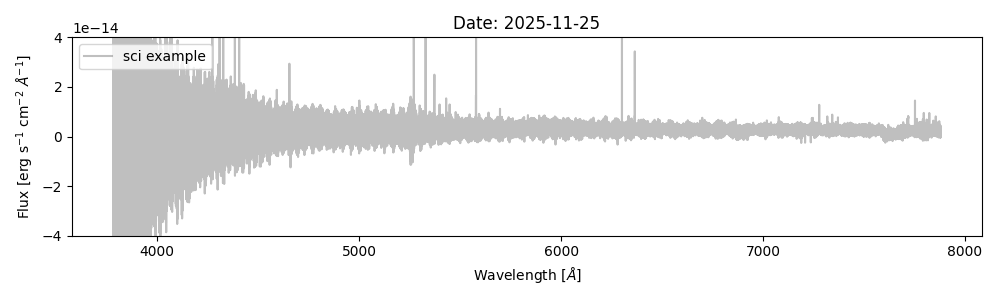

In [93]:
def sky_subtraction(specs, info, peak_sigma_sky=3, peak_sigma_sci=4, plot=False, tol=0.2, ox_width=4):
    v1 = []
    v1_info = []
    v2 = []
    v2_info = []
    v3 = []
    v3_info = []
    v4 = []
    v4_info = []
    
    sky2_bool = False
    sky1_bool = False
    
    def _first_corr_wave(v, ox_width=4.0, oxygen_line_air=5577.346680):
        """
        For each spectrum in `v`, fit the [OI] 5577 Å line on the AIR wavelength grid,
        compute the RV via the relativistic formula, correct the AIR wavelengths,
        then convert to VACUUM using `air_to_vacuum`.
        """
        new_v = []
        c_kms = c_light.to_value(u.km/u.s)

        for i, seg in enumerate(v):
            wave_air = np.asarray(seg['WAVE_AIR'][0], dtype=float)
            flux     = np.asarray(seg['FLUX_TELL_CAL'][0], dtype=float)

            fin = np.isfinite(wave_air) & np.isfinite(flux)
            wa, fl = wave_air[fin], flux[fin]

            wmin, wmax = oxygen_line_air - ox_width, oxygen_line_air + ox_width
            sel = (wa > wmin) & (wa < wmax)

            factor = 1.0

            if np.count_nonzero(sel) >= 5:
                x, y = wa[sel], fl[sel]
                c0   = float(np.median(y))
                amp0 = float(np.nanmax(y) - c0)
                std0 = 1.0

                const = models.Const1D(amplitude=c0)
                gauss = models.Gaussian1D(amplitude=amp0,
                                        mean=oxygen_line_air, stddev=std0)
                model  = const + gauss
                fitter = fitting.LevMarLSQFitter()
                fit    = fitter(model, x, y)

                center = float(fit[1].mean.value)

                z    = (center / oxygen_line_air) - 1.0
                beta = ((1.0 + z)**2 - 1.0) / ((1.0 + z)**2 + 1.0)

                factor = np.sqrt((1.0 - beta) / (1.0 + beta))

            seg['WAVE_AIR'] = seg['WAVE_AIR'] * factor  

            out = air_to_vac(seg['WAVE_AIR'][0] * u.AA)
            try:
                wave_vac = out.to_value(u.AA)
            except AttributeError:
                wave_vac = np.asarray(out, dtype=float)

            seg['WAVE'] = np.array([wave_vac])  # keep same shape convention

            new_v.append(seg)

        return new_v

    def _create_fibre_B_spectrum(v):
        new_v = []
        for i in v:
            A = i['FLUX_TELL_CAL'][0]
            B = i['FLUX_CAL_SKYSUB'][0]
            fiberB_flux = A-B
            fiberB_err = np.sqrt(i['ERR_TELL_CAL'][0]**2 + i['ERR_CAL_SKYSUB'][0]**2)
            t = Table(i)                       # make it a Table
            n = len(t)
            t['FLUX_FIBER_B'] = np.asarray([fiberB_flux], dtype='f4')     # length n
            t['ERR_FIBER_B']  = np.asarray([fiberB_err],  dtype='f4')   

            hdu = fits.BinTableHDU(t)
            i = hdu.data 
            new_v.append(i)
        return new_v
    
    # Separate exposures per version, and check if there is sky2
    for key in specs.keys():
        if 'v1' in key:
            print(key)
            v1.append(specs[key])
            v1_info.append(info[key])
        elif 'v2' in key:
            v2.append(specs[key])
            v2_info.append(info[key])
        elif 'v3' in key:
            v3.append(specs[key])
            v3_info.append(info[key])
        elif 'v4' in key:
            v4.append(specs[key])
            v4_info.append(info[key])
        elif 'sky1' in key:
            specs[key] = _first_corr_wave([specs[key]], ox_width=ox_width)[0]
            sky1_bool = True
            specs[key] = _create_fibre_B_spectrum([specs[key]])[0]
        elif 'sky2' in key:
            sky2_bool = True
            specs[key] = _first_corr_wave([specs[key]], ox_width=ox_width)[0]
            specs[key] = _create_fibre_B_spectrum([specs[key]])[0]
            
    # first correct the wrong wavelegth by identifying the oxigen line:
    if v1:
        v1 = _first_corr_wave(v1, ox_width=ox_width)
    if v2:
        v2 = _first_corr_wave(v2, ox_width=ox_width)
    if v3:
        v3 = _first_corr_wave(v3, ox_width=ox_width)
    if v4:
        v4 = _first_corr_wave(v4, ox_width=ox_width)
    
    if v1:
        v1 = _create_fibre_B_spectrum(v1)
    if v2:
        v2 = _create_fibre_B_spectrum(v2)
    if v3:
        v3 = _create_fibre_B_spectrum(v3)
    if v4:
        v4 = _create_fibre_B_spectrum(v4)

    #subtract sky continuum and find lines
    def _subtract_sky_continuum(v, sky, specs, plot=False, degree=1, peak_sigma=3, A_or_B='A'):
        if A_or_B == 'A':
            keys_to_use = 'FLUX_TELL_CAL'
            keys_to_use_err = 'ERR_TELL_CAL'
        if A_or_B == 'B':
            keys_to_use = 'FLUX_FIBER_B'
            keys_to_use_err = 'ERR_FIBER_B'
        for key in specs.keys():
            if sky in key:
                date = key.split('/')[1]
                sky_spectrum = specs[key][keys_to_use][0]
                sky_spectrum_error = specs[key][keys_to_use_err][0]
                wave = specs[key]['WAVE'][0]
        
        # Fit a nth order polynomial to sky spectrum taking into account the errors, using astropy modeling and sigma clipping
        model = models.Polynomial1D(degree=degree, c0=np.max(sky_spectrum))
        fit = fitting.LinearLSQFitter()
        mask = np.isfinite(sky_spectrum) & np.isfinite(sky_spectrum_error)
        or_fit = fitting.FittingWithOutlierRemoval(fit, sigma_clip, niter=3, sigma=3)
        dF = sky_spectrum_error[mask]
        weights = 1.0 / dF 
        fitted_sky, m = or_fit(model, wave[mask], sky_spectrum[mask], weights=weights)
        
        fitted_sky_arr = fitted_sky(wave)
        filtered_data = np.ma.masked_array(sky_spectrum[mask], mask=m)
        
        if plot:
            plt.figure(figsize=(10, 6))
            plt.title(f'{date} {sky}')
            plt.scatter(wave[mask], sky_spectrum[mask], facecolors='none', label="Clipped Data", alpha=0.3, edgecolors='k')
            plt.plot(wave[mask], filtered_data, "ko", label="Fitted Data")
            plt.plot(wave[mask], fitted_sky_arr[mask], c='crimson', label='Fitted Model')
            plt.xlabel(r'Wavelength [$\AA$]')
            plt.ylabel(r'Sky Spectrum [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]')
            plt.ylim(-3e-14, 3e-14)
            plt.show()
            
        v_new = []
        for i in v:
            i[keys_to_use][0] = i[keys_to_use][0] - fitted_sky_arr
            v_new.append(i)
            
        peaks, props = find_peaks(sky_spectrum-fitted_sky_arr, width=4)
        good_peaks = []
        for i in peaks:
            if sky_spectrum[i]/sky_spectrum_error[i]>peak_sigma:
                good_peaks.append(i)
        lines = []
        for i, pk in enumerate(good_peaks):
            mu0 = wave[pk]
            lines.append(mu0)
        return v_new, lines
    
    #v1 and v2 goes with sky 1
    #v3 and v4 goes with sky 2 if exist
    #sky cont subtraction and finding sky lines in sky
    if sky1_bool or sky2_bool:
        if v1:        
            v1, peaks_sky1 = _subtract_sky_continuum(v1, 'sky1', specs, plot=False, peak_sigma=peak_sigma_sky, A_or_B='A')
            v1, peaks_sky1B = _subtract_sky_continuum(v1, 'sky1', specs, plot=False, peak_sigma=peak_sigma_sky, A_or_B='B')
        if v2:
            v2, _ = _subtract_sky_continuum(v2, 'sky1', specs, peak_sigma=peak_sigma_sky, A_or_B='A')
            v2, _ = _subtract_sky_continuum(v2, 'sky1', specs, peak_sigma=peak_sigma_sky, A_or_B='B')
        if v3:
            if sky2_bool:
                v3, peaks_sky2 = _subtract_sky_continuum(v3, 'sky2', specs, plot=False, peak_sigma=peak_sigma_sky, A_or_B='A')
                v3, peaks_sky2B = _subtract_sky_continuum(v3, 'sky2', specs, plot=False, peak_sigma=peak_sigma_sky, A_or_B='B')
            else:
                v3, _ = _subtract_sky_continuum(v3, 'sky1', specs, peak_sigma=peak_sigma_sky, A_or_B='A')
                v3, _ = _subtract_sky_continuum(v3, 'sky1', specs, peak_sigma=peak_sigma_sky, A_or_B='B')
        if v4:
            if sky2_bool:
                v4, _ = _subtract_sky_continuum(v4, 'sky2', specs, peak_sigma=peak_sigma_sky, A_or_B='A')
                v4, _ = _subtract_sky_continuum(v4, 'sky2', specs, peak_sigma=peak_sigma_sky, A_or_B='B')
            else:
                v4, _ = _subtract_sky_continuum(v4, 'sky1', specs, peak_sigma=peak_sigma_sky)
                v4, _ = _subtract_sky_continuum(v4, 'sky1', specs, peak_sigma=peak_sigma_sky, A_or_B='B')

    # match sky lines in sci exposure and sky observation
    def _match_sky_lines(skylines, spec, sigma_sky=4, tol=0.2, A_or_B='A'):
        if A_or_B == 'A':
            peak, props = find_peaks(spec['FLUX_TELL_CAL'][0], width=4)
            good_peaks = []
            y = spec['FLUX_TELL_CAL'][0]
            err = spec['ERR_TELL_CAL'][0]
            wave = spec['WAVE'][0]
        if A_or_B == 'B':
            peak, props = find_peaks(spec['FLUX_FIBER_B'][0], width=4)
            good_peaks = []
            y = spec['FLUX_FIBER_B'][0]
            err = spec['ERR_FIBER_B'][0]
            wave = spec['WAVE'][0]

        for i in peak:
            if y[i]/err[i]>sigma_sky:
                good_peaks.append(wave[i])
        good_set = np.array(good_peaks)
        good = sorted(good_set)
        #tolerance of the wavelegth matching
        def in_tol(p):
            i = bisect.bisect_left(good, p - tol)
            j = bisect.bisect_right(good, p + tol)
            return i < j
        matched = [p for p in skylines if in_tol(p)]
        return matched
    
    # very close pairs are separated from the initial ones to treat them differently
    def split_close_pairs(matched, tol=0.15, consider_sorted=True):
   
        a = np.asarray(matched, dtype=float)
        n = a.size
        if n == 0:
            return [], []

        # choose the order to test adjacency
        idx = np.argsort(a) if consider_sorted else np.arange(n)
        s = a[idx]

        kept_idx_sorted = []
        pair_idx_sorted = []
        i = 0
        while i < n - 1:
            if (s[i+1] - s[i]) < tol:
                pair_idx_sorted.append((i, i+1))
                i += 2  # consume both
            else:
                kept_idx_sorted.append(i)
                i += 1
        if i == n - 1:  # last unpaired element
            kept_idx_sorted.append(i)

        # map back to original indices
        kept_indices = idx[np.array(kept_idx_sorted, dtype=int)]
        pair_indices = [(int(idx[i]), int(idx[j])) for (i, j) in pair_idx_sorted]

        # build outputs
        mask_keep = np.zeros(n, dtype=bool)
        mask_keep[kept_indices] = True
        matched_clean = a[mask_keep].tolist()  # original order preserved
        matched2 = [(float(a[i]), float(a[j])) for (i, j) in pair_indices]

        return matched_clean, matched2
    
    # search sky lines
    def _find_sky_lines(skylines, v, version='', sigma_sky=4, sky='sky1', tol=0.2, A_or_B='A'):
        centers = []
        for vj in v:
            matched2 = _match_sky_lines(skylines, vj, sigma_sky=sigma_sky, tol=tol, A_or_B=A_or_B)
            matched, matched_pair = split_close_pairs(matched2)        
            for cent in matched:
                cond = _fit_gaussian(vj, cent, window_width=0.2, A_or_B=A_or_B)
                if cond:
                    centers.append(cent)
                
            for cen in matched_pair:
                cond = _fit_2gaussian(vj, cen[0], cen[1], window_width=0.2, A_or_B=A_or_B)
                if cond:
                    centers.append(cen[0])
                    centers.append(cen[1])          
        return np.array(centers)

    # gaussian fittinf tests
    def _fit_gaussian(v, central_wave, window_width, A_or_B='A'):
        if A_or_B == 'A':
            keys_to_use = 'FLUX_TELL_CAL'
            keys_to_use_err = 'ERR_TELL_CAL'
        if A_or_B == 'B':
            keys_to_use = 'FLUX_FIBER_B'
            keys_to_use_err = 'ERR_FIBER_B'
        x = v['WAVE'][0]
        y = v[keys_to_use][0]
        yerr = v[keys_to_use_err][0]

        yerr = yerr[(x>central_wave-window_width)&(x<central_wave+window_width)]
        y = y[(x>central_wave-window_width)&(x<central_wave+window_width)]
        x = x[(x>central_wave-window_width)&(x<central_wave+window_width)]
        mask = np.isfinite(y) & np.isfinite(yerr)
        yerr = yerr[mask]
        y = y[mask]
        x = x[mask]
        
        c0 = np.median(y)
        amp0 = y.max()
        
        # check the S_N in the middle of the array
        S_N = y[len(y)//2]/yerr[len(y)//2]
        if S_N>5:
            return True
        std0 = window_width/10 / 2.355
        const = models.Const1D(amplitude=c0)
        gauss = models.Gaussian1D(amplitude=amp0, mean=central_wave, stddev=std0)

        model = const + gauss 
        fitter = fitting.LevMarLSQFitter(calc_uncertainties=True)

        try:
            fit = fitter(model, x, y, weights=1/yerr)
        except:
            return False
        
        # values tests, 
        try:
            amp   = float(fit[1].amplitude.value)
            amp_error = float(fit[1].amplitude.std)
            width = float(fit[1].stddev.value)
            width_error = float(fit[1].stddev.std)
            center = float(fit[1].mean.value)
            center_error = float(fit[1].mean.std)
            const = float(fit[0].amplitude.value)
            FWHM = 2.355 * width
        except TypeError:
            return False
        
        if amp<=0:
            return False
        # false if the error is greater than the 50% of the amplitude
        if amp_error/amp>0.3:
            return False
        if width_error/width>0.5:
            return False
        if center_error>0.01:
            return 
        if FWHM<0.05:
            return False
        if np.abs(center-central_wave)>0.01:
            return False
        return True
    
    # fitting two close gaussians test
    def _fit_2gaussian(v, cen1, cen2, window_width, A_or_B='A'):
        x = v['WAVE'][0]
        if A_or_B == 'A':
            y = v['FLUX_TELL_CAL'][0]
            yerr = v['ERR_TELL_CAL'][0]
        if A_or_B == 'B':
            y = v['FLUX_FIBER_B'][0]
            yerr = v['ERR_FIBER_B'][0]

        yerr = yerr[(x>cen1-window_width)&(x<cen2+window_width)]
        y = y[(x>cen1-window_width)&(x<cen2+window_width)]
        x = x[(x>cen1-window_width)&(x<cen2+window_width)]
        # mask non finite values
        mask = np.isfinite(y) & np.isfinite(yerr)
        yerr = yerr[mask]
        y = y[mask]
        x = x[mask]
        S_N = y[len(y)//2]/yerr[len(y)//2]
        if S_N>5:
            return True
        c0 = np.median(y)
        amp0 = y.max()
        std0 = window_width/25 / 2.355
        const = models.Const1D(amplitude=c0)
        gauss = models.Gaussian1D(amplitude=amp0, mean=cen1, stddev=std0)
        gauss2 = models.Gaussian1D(amplitude=amp0, mean=cen2, stddev=std0)
        model = const + gauss + gauss2
        fitter = fitting.LevMarLSQFitter(calc_uncertainties=True)

        try:
            fit = fitter(model, x, y, weights=1/yerr)
        except:
            return False
        try:
            amp   = float(fit[1].amplitude.value)
            amp_error = float(fit[1].amplitude.std)
            amp2  = float(fit[2].amplitude.value)
            amp2_error = float(fit[2].amplitude.std)
            
        except TypeError:
            return False
        if amp_error/amp>0.75:
            return False
        if amp2_error/amp2>0.75:
            return False
        if amp<=0 or amp2<0:
            return False
        return True
    # MASK skylines
    if sky1_bool or sky2_bool:
        if v1:
            c1A = _find_sky_lines(peaks_sky1, v1, version='v1', sigma_sky=peak_sigma_sci, sky='sky1', tol=tol, A_or_B='A')
            c1B = _find_sky_lines(peaks_sky1B, v1, version='v1', sigma_sky=peak_sigma_sci, sky='sky1', tol=tol, A_or_B='B')
        if v2:
            c2A = _find_sky_lines(peaks_sky1, v2, version='v2', sigma_sky=peak_sigma_sci, sky='sky1', tol=tol, A_or_B='A')
            c2B = _find_sky_lines(peaks_sky1B, v2, version='v2', sigma_sky=peak_sigma_sci, sky='sky1', tol=tol, A_or_B='B')
        if v3:
            if sky2_bool:
                c3A = _find_sky_lines(peaks_sky2, v3, version='v3', sigma_sky=peak_sigma_sci, sky='sky2', tol=tol, A_or_B='A')
                c3B = _find_sky_lines(peaks_sky2B, v3, version='v3', sigma_sky=peak_sigma_sci, sky='sky2', tol=tol, A_or_B='B')
            else:
                c3A = _find_sky_lines(peaks_sky1, v3, version='v3', sigma_sky=peak_sigma_sci, sky='sky1', tol=tol, A_or_B='A')
                c3B = _find_sky_lines(peaks_sky1B, v3, version='v3', sigma_sky=peak_sigma_sci, sky='sky1', tol=tol, A_or_B='B')
        if v4:
            if sky2_bool:
                c4A = _find_sky_lines(peaks_sky2, v4, version='v4', sigma_sky=peak_sigma_sci, sky='sky2', tol=tol, A_or_B='A')
                c4B = _find_sky_lines(peaks_sky2B, v4, version='v4', sigma_sky=peak_sigma_sci, sky='sky2', tol=tol, A_or_B='B')
            else:
                c4A = _find_sky_lines(peaks_sky1, v4, version='v4', sigma_sky=peak_sigma_sci, sky='sky1', tol=tol, A_or_B='A')
                c4B = _find_sky_lines(peaks_sky1B, v4, version='v4', sigma_sky=peak_sigma_sci, sky='sky1', tol=tol, A_or_B='B')

    def _doppler_shift(wave, delta, relativistic=True):
        beta = delta * u.km / u.s / c.c.to(u.km/u.s)
        if relativistic:
            factor = np.sqrt((1 + beta) / (1 - beta))
        else:
            factor = 1.0 + beta
            
        return wave / factor
    
    def _vel_corr(v, info):
        for i in range(len(v)):
            vj = v[i]
            vj_inf = info[i]
            delta = vj_inf['deldot_km_s']
            wave = vj['WAVE']
            new_wave = _doppler_shift(wave, delta)
            data = v[i]
            new_wave = np.asarray(new_wave)
            assert len(new_wave) == len(data)

            t = Table(data, copy=False)
            t['Wave_RV_Corr'] = new_wave

            v[i] = fits.BinTableHDU(t).data
            
        return v
    
    pairsA = []
    pairsB = []
    if v1:
        v1 = _vel_corr(v1, v1_info)
        if sky1_bool or sky2_bool:
            pairsA.append((v1, c1A))
            pairsB.append((v1, c1B))
    if v2:
        v2 = _vel_corr(v2, v2_info)
        if sky1_bool or sky2_bool:
            pairsA.append((v2, c2A))
            pairsB.append((v2, c2B))
    if v3:
        v3 = _vel_corr(v3, v3_info)
        if sky1_bool or sky2_bool:
            pairsA.append((v3, c3A))
            pairsB.append((v3, c3B))
    if v4:
        v4 = _vel_corr(v4, v4_info)
        if sky1_bool or sky2_bool:
            pairsA.append((v4, c4A))
            pairsB.append((v4, c4B))

    # merge all the lines found
    if sky1_bool or sky2_bool:
        arrsA = [np.asarray(lst, float) for cond, lst in pairsA if cond]
        merged = np.sort(np.concatenate(arrsA)) if arrsA else np.array([], float)
        merged_uniqueA = np.unique(merged)
        arrsB = [np.asarray(lst, float) for cond, lst in pairsB if cond]
        mergedB = np.sort(np.concatenate(arrsB)) if arrsB else np.array([], float)
        merged_uniqueB = np.unique(mergedB)
    else:
        merged_uniqueA = np.array([], float)
        merged_uniqueB = np.array([], float)
        
    all_obs = []
    if v1:
        for i in range(len(v1)):
            all_obs.append(v1[i])
    if v2:    
        for i in range(len(v2)):
            all_obs.append(v2[i])
    if v3:   
        for i in range(len(v3)):
            all_obs.append(v3[i]) 
    if v4:
        for i in range(len(v4)):        
            all_obs.append(v4[i])  
    
    for key in specs.keys():
        date = key.split('/')[1]
        if 'sky1' in key:
            sky_spectrum_A = specs[key]['FLUX_TELL_CAL'][0]
            sky_wave_A = specs[key]['WAVE'][0]
            sky_spectrum_B = specs[key]['FLUX_FIBER_B'][0]
            sky_wave_B = specs[key]['WAVE'][0]
        if 'sky2' in key:
            sky_spectrum2_A = specs[key]['FLUX_TELL_CAL'][0]
            sky_wave2_A = specs[key]['WAVE'][0]
            sky_spectrum2_B = specs[key]['FLUX_FIBER_B'][0]
            sky_wave2_B = specs[key]['WAVE'][0]

    if plot:
        plt.figure(figsize=(10, 3))
        if sky1_bool:
            plt.plot(sky_wave_A, sky_spectrum_A, c='tab:blue', label='sky', alpha=0.7)
        if sky2_bool:
            plt.plot(sky_wave2_A, sky_spectrum2_A, c='brown', label='sky2', alpha=0.5)
        plt.plot(all_obs[0]['WAVE'][0], all_obs[0]['FLUX_TELL_CAL'][0], alpha=0.5, c='gray', label='sci example')
        
        j=0
        for i in merged_uniqueA:
            if j==0:
                plt.axvline(i, alpha=0.7, lw=1, c='gray', label='detected lines', ls='--')
                j=1
            else:
                plt.axvline(i, alpha=0.3, lw=1, c='gray', ls='--')
                    
        plt.ylim(-4e-14, 4e-14)
        plt.xlabel(r'Wavelength [$\AA$]')
        plt.ylabel(r'Flux [erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$]')

        plt.title(f'Date: {date[:4]}-{date[4:6]}-{date[6:]}')
        plt.legend(loc='upper left')
        plt.tight_layout()
        plt.show()

    return np.array(all_obs), merged_uniqueA, merged_uniqueB

print(visit_directories[0])
specsvisit1, info_obs1 = fits_in_vistit(visit_directories[0])
allobs1, lines1A, lines1B = sky_subtraction(specsvisit1, info_obs1, peak_sigma_sky=3, peak_sigma_sci=3, plot=True) 

data/20251126/ESPRE.2025-11-26T08:30:21.040/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-11-26T08:30:21.040.fits
data/20251126/ESPRE.2025-11-26T08:40:57.404/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-11-26T08:40:57.403.fits
data/20251126/ESPRE.2025-11-26T08:51:34.033/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-11-26T08:51:34.032.fits


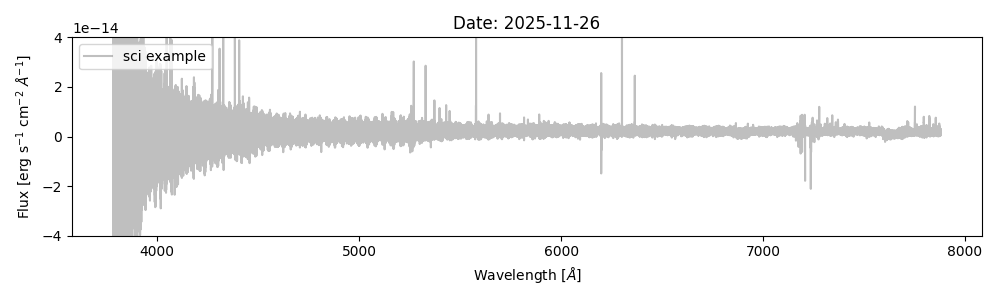

In [57]:
specsvisit2, info_obs2 = fits_in_vistit(visit_directories[1])
allobs2, lines2A, lines2B = sky_subtraction(specsvisit2, info_obs2, peak_sigma_sky=3, peak_sigma_sci=3, plot=True) 

data/20251127/ESPRE.2025-11-27T08:42:38.527/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-11-27T08:42:38.526.fits
data/20251127/ESPRE.2025-11-27T08:53:14.679/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-11-27T08:53:14.678.fits
data/20251127/ESPRE.2025-11-27T08:32:02.674/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-11-27T08:32:02.674.fits


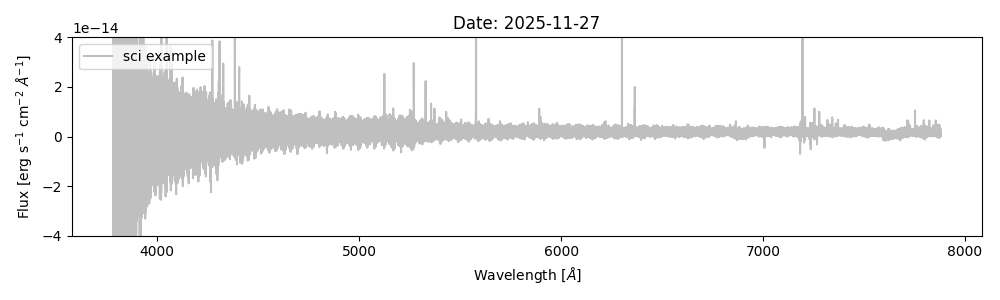

In [58]:
specvisit3, info_obs3 = fits_in_vistit(visit_directories[2])
allobs3, lines3A, lines3B = sky_subtraction(specvisit3, info_obs3, peak_sigma_sky=3, peak_sigma_sci=3, plot=True)

data/20251204/ESPRE.2025-12-04T08:14:54.141/TOO_MOV_3I-ATLAS-v2_S1D_FINAL_A_2025-12-04T08:14:54.141.fits
data/20251204/ESPRE.2025-12-04T07:49:34.763/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-12-04T07:49:34.762.fits
data/20251204/ESPRE.2025-12-04T07:38:58.537/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-12-04T07:38:58.537.fits
data/20251204/ESPRE.2025-12-04T08:25:29.796/TOO_MOV_3I-ATLAS-v2_S1D_FINAL_A_2025-12-04T08:25:29.795.fits
data/20251204/ESPRE.2025-12-04T07:28:22.631/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-12-04T07:28:22.630.fits
data/20251204/ESPRE.2025-12-04T08:04:18.168/TOO_MOV_3I-ATLAS-v2_S1D_FINAL_A_2025-12-04T08:04:18.168.fits


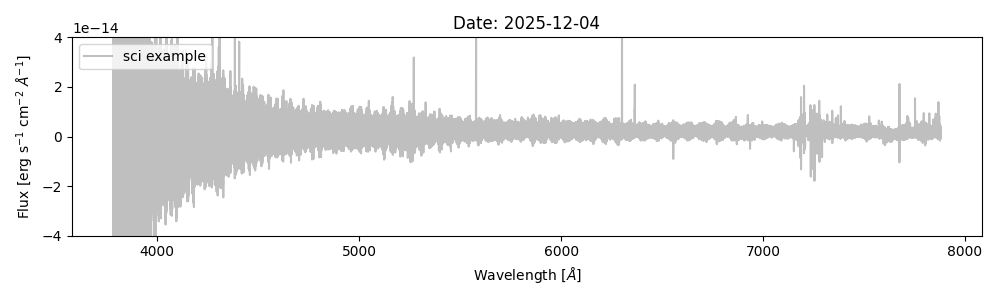

In [59]:
specsvisit4, info_obs4 = fits_in_vistit(visit_directories[3])
allobs4, lines4A, lines4B = sky_subtraction(specsvisit4, info_obs4, peak_sigma_sky=3, peak_sigma_sci=3, plot=True)

data/20251206/ESPRE.2025-12-06T07:29:08.145/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-12-06T07:29:08.145.fits
data/20251206/ESPRE.2025-12-06T07:39:44.328/TOO_MOV_3I-ATLAS-v1_S1D_FINAL_A_2025-12-06T07:39:44.327.fits


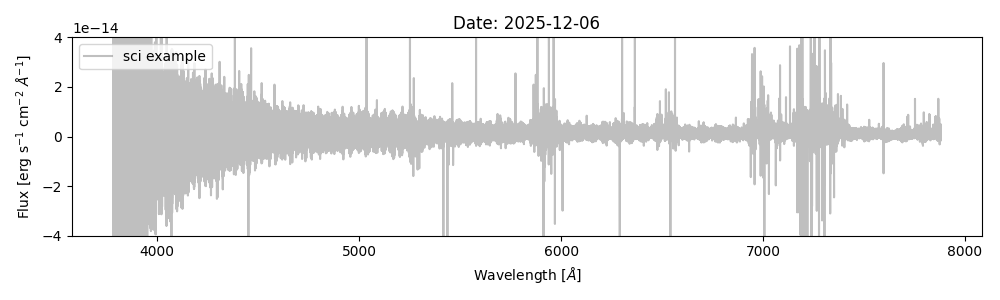

In [95]:
specsvisit5, info_obs5 = fits_in_vistit(visit_directories[4])
allobs5, lines5A, lines5B = sky_subtraction(specsvisit5, info_obs5, peak_sigma_sky=3, peak_sigma_sci=3, plot=True)

In [61]:
# plot the dispersions vs the rsun
rsun = [np.mean([info_obs1[key]['r_au'] for key in info_obs1 if 'sky' not in key and 'solar' not in key]),
        np.mean([info_obs2[key]['r_au'] for key in info_obs2 if 'sky' not in key and 'solar' not in key]),
        np.mean([info_obs3[key]['r_au'] for key in info_obs3 if 'sky' not in key and 'solar' not in key]),
        np.mean([info_obs4[key]['r_au'] for key in info_obs4 if 'sky' not in key and 'solar' not in key]),
        np.mean([info_obs5[key]['r_au'] for key in info_obs5 if 'sky' not in key and 'solar' not in key])]

rdot = [np.mean([info_obs1[key]['rdot_km_s'] for key in info_obs1 if 'sky' not in key and 'solar' not in key]),
        np.mean([info_obs2[key]['rdot_km_s'] for key in info_obs2 if 'sky' not in key and 'solar' not in key]),
        np.mean([info_obs3[key]['rdot_km_s'] for key in info_obs3 if 'sky' not in key and 'solar' not in key]),
        np.mean([info_obs4[key]['rdot_km_s'] for key in info_obs4 if 'sky' not in key and 'solar' not in key]),
        np.mean([info_obs5[key]['rdot_km_s'] for key in info_obs5 if 'sky' not in key and 'solar' not in key])]

rsun = np.array(rsun)
rdot = np.array(rdot)

def nan_near_centers(wave, values, centers, tol=0.2):
    wave = np.asarray(wave, float)
    vals = np.array(values, float, copy=True)
    c = np.sort(np.asarray(centers, float))
    if c.size == 0:
        return vals, np.zeros_like(wave, dtype=bool)
    idx = np.searchsorted(c, wave)
    left  = c[np.clip(idx-1, 0, c.size-1)]
    right = c[np.clip(idx,   0, c.size-1)]
    near = (np.abs(wave - left) <= tol) | (np.abs(wave - right) <= tol)
    vals[near] = np.nan
    return vals, near


def stack_fixed(
    obs,
    lines=None,
    tol=0.2,
    flux_key='FLUX_TELL_CAL',
    err_key='ERR_TELL_CAL',
    wave_key='WAVE',
    rv_key='Wave_RV_Corr',
    ref_idx=0,              # anchor grid to obs[ref_idx] RV wavelengths
    ref_grid=None,          # or pass explicit reference RV grid
    clip_sigma=None,        # per-sample-σ clipping (e.g., 3.0)
    clip_iters=3,
    night_lengths=None,     # list of counts per night; must sum to len(obs)
    ax=None,                # optional matplotlib Axes
    interp_kind='linear',   # 'linear' | 'spline' | 'pchip' | 'akima'
    spline_degree=3,        # spline degree (used when interp_kind='spline')
    visit_directories=None,
    nightly = False,
    extra=True, # for recursive per nigth  
):
    """
    Stack spectra onto one reference RV grid using inverse-variance weights, with
    optional sky-line masking and per-sample-σ clipping. Interpolation method is
    selectable (linear/spline/PCHIP/Akima).

    Returns a pandas.DataFrame with columns:
      WAVE, FLUX_STACK, ERR_STACK, NCONTRIB,
      FLUX_STACK_SKYSUB, ERR_STACK_SKYSUB, NCONTRIB_SKYSUB
    """
    
    if extra:
        # ---------------- helpers ----------------
        def as_arrays(rec):
            w  = np.asarray(rec[wave_key][0], float)
            f  = np.asarray(rec[flux_key][0], float)
            e  = np.asarray(rec[err_key][0],  float)
            wr = np.asarray(rec[rv_key][0], float)
            return w, wr, f, e
    else:
        def as_arrays(rec):
            w  = np.asarray(rec[wave_key], float)
            f  = np.asarray(rec[flux_key], float)
            e  = np.asarray(rec[err_key],  float)
            wr = np.asarray(rec[rv_key], float)
            return w, wr, f, e

    def _make_evaluator(xp, fp):
        """
        Build an interpolator callable y(x). No extrapolation (fills NaN outside domain).
        Falls back to linear if SciPy isn't available or data is too short.
        """
        xp = np.asarray(xp, float)
        fp = np.asarray(fp, float)
        m = np.isfinite(xp) & np.isfinite(fp)
        if m.sum() < 2:
            return lambda x: np.full_like(np.asarray(x, float), np.nan, dtype=float)

        xp = xp[m]; fp = fp[m]
        # sort & unique in case of tiny jitter/duplicates
        order = np.argsort(xp)
        xp = xp[order]; fp = fp[order]
        uniq = np.diff(xp, prepend=xp[0]-1.0) > 0
        xp = xp[uniq]; fp = fp[uniq]

        if interp_kind == 'linear':
            def f_lin(x):
                x = np.asarray(x, float)
                y = np.interp(x, xp, fp)
                y[(x < xp.min()) | (x > xp.max())] = np.nan
                return y
            return f_lin

        # Try SciPy-based methods
        try:
            import scipy.interpolate as si
            if interp_kind == 'spline':
                k = max(1, min(int(spline_degree), len(xp)-1))
                spl = si.UnivariateSpline(xp, fp, k=k, s=0)
                def f_spl(x):
                    x = np.asarray(x, float)
                    y = spl(x)
                    y[(x < xp.min()) | (x > xp.max())] = np.nan
                    return y
                return f_spl
            elif interp_kind == 'pchip':
                p = si.PchipInterpolator(xp, fp, extrapolate=False)
                def f_pchip(x):
                    x = np.asarray(x, float)
                    y = p(x)
                    y[(x < xp.min()) | (x > xp.max())] = np.nan
                    return y
                return f_pchip
            elif interp_kind == 'akima':
                a = si.Akima1DInterpolator(xp, fp)
                def f_ak(x):
                    x = np.asarray(x, float)
                    y = a(x)
                    y[(x < xp.min()) | (x > xp.max())] = np.nan
                    return y
                return f_ak
            else:
                # unknown kind -> linear fallback
                return _make_evaluator(xp, fp)  # call back with 'linear'
        except Exception:
            # SciPy not available or failed -> linear fallback
            def f_lin(x):
                x = np.asarray(x, float)
                y = np.interp(x, xp, fp)
                y[(x < xp.min()) | (x > xp.max())] = np.nan
                return y
            return f_lin

    def apply_nan_near(w, f):
        if lines is None:
            return f.copy()
        g, _ = nan_near_centers(w, f, lines, tol=tol)
        return g
    def _safe_invvar(e, rel=0.10, abs_floor=0.0):
        """
        Safe 1/e^2 with a variance floor:
        denom = e^2 + floor^2
        floor = max(abs_floor, rel * median(e_valid))
        Returns NaN where denom is invalid.
        """
        e = np.asarray(e, float)
        inv = np.full_like(e, np.nan)

        valid = np.isfinite(e) & (e > 0)
        if valid.any():
            med = np.nanmedian(e[valid])
            floor = max(abs_floor, rel * med)
        else:
            floor = abs_floor

        denom = e*e + floor*floor
        m = np.isfinite(denom) & (denom > 0)
        np.divide(1.0, denom, out=inv, where=m)
        return inv

    def robust_weighted_stack(
        Fmat,                # shape: (nspec, nλ)
        Wmat,                # same shape; typically 1/σ^2 if you want err = 1/sqrt(sum W)
        Emat=None,           # unused for clipping here; kept for API symmetry
        sigma=None,          # e.g., 3.0; if None or <=0, no clipping
        iters=3,             # max clipping iterations
        min_contrib=2        # minimum number of included spectra required per column
    ):
        
        Fmat = np.asarray(Fmat, dtype=float)
        Wmat = np.asarray(Wmat, dtype=float)
        
        valid = np.isfinite(Fmat) & np.isfinite(Wmat) & (Wmat > 0)

        if Emat is not None:
            Emat = np.asarray(Emat, dtype=float)
            used_mask = valid

        if sigma is not None and sigma > 0:
            # Mask anything invalid or non-positive weight
            Fwork_mask = ~(valid)

            Fwork = np.ma.array(Fmat, mask=Fwork_mask, copy=False)

            sc = SigmaClip(
                sigma=sigma,
                maxiters=iters,
                cenfunc=np.nanmedian,
                stdfunc=np.nanstd
            )
            clipped = sc(Fwork, axis=0)
            clipped_mask = np.asarray(clipped.mask, dtype=bool)
        else:
            clipped_mask = np.zeros_like(Fmat, dtype=bool)

        # Start with basic validity: finite flux AND positive weight

        # when forming effective weights for sums, turn only the *used* entries into numbers
        Weff = np.where(valid, np.nan_to_num(Wmat, nan=0.0, posinf=0.0, neginf=0.0), 0.0)
        if sigma is not None and sigma > 0:
            # ... after sigma clipping, recompute used_mask
            used_mask = valid & ~clipped_mask
            Weff = np.where(used_mask, np.nan_to_num(Wmat, nan=0.0, posinf=0.0, neginf=0.0), 0.0)
        else:
            used_mask = valid
            
        # Weighted sums over rows
        Weff = np.where(used_mask, Wmat, np.nan)
        num  = np.nansum(Weff * Fmat, axis=0)
        den  = np.nansum(Weff,        axis=0)
        ncon = np.nansum(used_mask,   axis=0)

        # Apply min_contrib requirement
        ok = np.isfinite(den) & (den > 0) & (ncon >= int(min_contrib))

        flux = np.full(Fmat.shape[1], np.nan, dtype=float)
        err  = np.full(Fmat.shape[1], np.nan, dtype=float)

        flux[ok] = num[ok] / den[ok]
        err[ok]  = 1.0 / np.sqrt(den[ok])
        return flux, err, ncon


    def _robust_span(y):
        lo, hi = np.nanpercentile(y, [0.2, 99.8])
        return hi - lo

    # ---------------- reference grid ----------------
    if ref_grid is not None:
        W = np.asarray(ref_grid, float)
    else:
        _, W, _, _ = as_arrays(obs[ref_idx])

    # ---------------- interpolate all spectra onto W ----------------
    F_list, E_list, WGT_list = [], [], []
    Fss_list, Ess_list, WGTss_list = [], [], []
    F_list2, W_list2 = [], []
    
    for r in obs:
        w, wr, f, e = as_arrays(r)
        # This are the original no line masking, if needed for plotting
        F_list2.append(f)
        W_list2.append(wr)
        # build evaluators on the RV-corrected x-grid
        f_eval = _make_evaluator(wr, f)
        e_eval = _make_evaluator(wr, e)

        # normal branch: interpolate flux and error; compute weights from interpolated error
        f_on_ref = f_eval(W)
        e_on_ref = e_eval(W)
        w_on_ref = _safe_invvar(e_on_ref)

        # This are the ones on ref frame, no line masking.
        F_list.append(f_on_ref)
        E_list.append(e_on_ref)
        WGT_list.append(w_on_ref)

        # sky-sub branch: mask ORIGINAL flux, then interpolate masked flux & error
        f_mask  = apply_nan_near(w, f)
        e_mask  = np.where(np.isfinite(f_mask), e, np.nan)

        fss_eval = _make_evaluator(wr, f_mask)
        ess_eval = _make_evaluator(wr, e_mask)

        f_on_ref_ss = fss_eval(W)
        e_on_ref_ss = ess_eval(W)
        w_on_ref_ss = _safe_invvar(e_on_ref_ss)

        Fss_list.append(f_on_ref_ss)
        Ess_list.append(e_on_ref_ss)
        WGTss_list.append(w_on_ref_ss)

    F    = np.vstack(F_list)
    E    = np.vstack(E_list)
    WGT  = np.vstack(WGT_list)

    Fss  = np.vstack(Fss_list)
    Ess  = np.vstack(Ess_list)
    WGTs = np.vstack(WGTss_list)

    
    flux_stack, err_stack, ncon = robust_weighted_stack(F,   WGT,  E,   sigma=clip_sigma, iters=clip_iters)
    flux_ss  = apply_nan_near(W, flux_stack)
    err_ss  = np.where(np.isfinite(f_mask), err_stack, np.nan)
    nss = np.where(np.isfinite(f_mask), ncon, 0)
    
    full_stack = pd.DataFrame({
                                'WAVE': W,
                                'FLUX_STACK': flux_stack,
                                'ERR_STACK': err_stack,
                                'NCONTRIB': ncon,
                                'FLUX_STACK_SKYSUB': flux_ss,
                                'ERR_STACK_SKYSUB': err_ss,
                                'NCONTRIB_SKYSUB': nss,
                            })
    if nightly:
        return full_stack
    
    results = {}
    results['Full_Stack'] = full_stack
    
    n_obs = len(obs)
    if night_lengths is None:
        night_lengths = [n_obs]
    night_lengths = list(map(int, night_lengths))
    total = sum(night_lengths)
    if total != n_obs:
        raise ValueError(f"night_lengths sum ({total}) != number of obs ({n_obs})")

    edges = np.concatenate(([0], np.cumsum(night_lengths)))
    #slices of each nigth
    slices = [slice(edges[k], edges[k+1]) for k in range(len(night_lengths))]
    
    for k, s in enumerate(slices):
        nigth = stack_fixed(
            obs[s],
            lines=lines,
            tol=tol,
            flux_key=flux_key,
            err_key=err_key,
            wave_key=wave_key,
            rv_key=rv_key,
            ref_idx=0,             
            ref_grid=ref_grid,          
            clip_sigma=clip_sigma,
            clip_iters=clip_iters,
            night_lengths=night_lengths,     
            ax=ax,               
            interp_kind=interp_kind,   
            spline_degree=spline_degree,
            visit_directories=visit_directories,
            nightly = True) 
        results[f'{visit_directories[k].split("/")[1]}'] = nigth
                                                                               
    # Now we are going to plot the per nigthstacks, but taking to the Wave_RV_Corr general grid, ie, W
    plot_list = []
    
    for k, s in enumerate(slices):
        nigth = results[f'{visit_directories[k].split("/")[1]}']
        nigth = stack_fixed(
                    obs[s],
                    lines=lines,
                    tol=tol,
                    flux_key=flux_key,
                    err_key=err_key,
                    wave_key=wave_key,
                    rv_key=rv_key,
                    ref_idx=ref_idx,             
                    ref_grid=W,          
                    clip_sigma=clip_sigma,
                    clip_iters=clip_iters,
                    night_lengths=night_lengths,     
                    ax=ax,               
                    interp_kind=interp_kind,   
                    spline_degree=spline_degree,
                    visit_directories=visit_directories,
                    nightly = True) 
        plot_list.append(nigth)
    
    global rsun
    if ax == None:
        fig, ax = plt.subplots(figsize=(10, 8))
        
    spans = [_robust_span(nigth['FLUX_STACK']) for nigth in plot_list]
    offset_step = 1.5 * np.nanmedian(spans) if np.isfinite(spans).any() else 0.0
    for k, nigth in enumerate(plot_list):
        ax.plot(nigth['WAVE'], nigth['FLUX_STACK']+ k * offset_step, alpha=0.8, c='cornflowerblue')
        date = visit_directories[k].split("/")[1]
        date = f'{date[:4]}-{date[4:6]}-{date[6:]}'
        
        ax.text(0.99 , (k * offset_step)-1e-14, f'{date} ({night_lengths[k]} obs, r = {rsun[k]:.2f} au)', 
                transform=ax.get_yaxis_transform(), ha='right', va='top', fontsize=8, color='black', alpha=0.7, )
    ax.set_xlabel('Wavelength [Å]')
    ax.set_ylabel('Mean flux per night (+ offset)')
    ax.set_ylim(-1.165e-13, 1.3e-12)
    fig.tight_layout()
    plt.show()
    
    return results


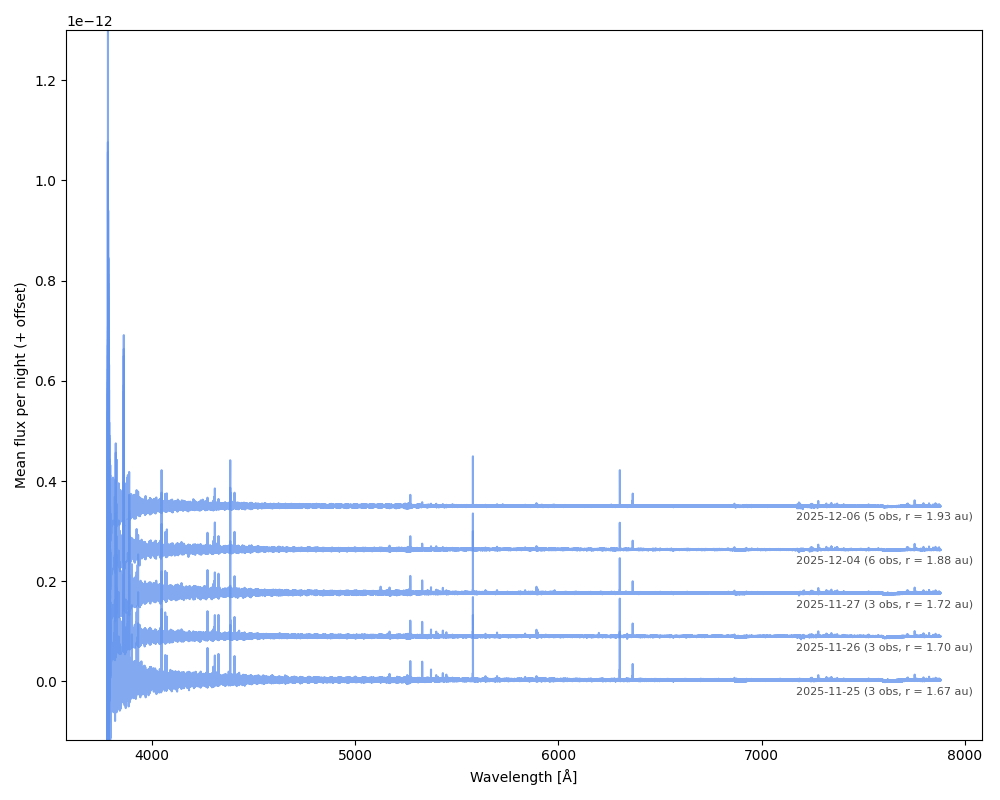

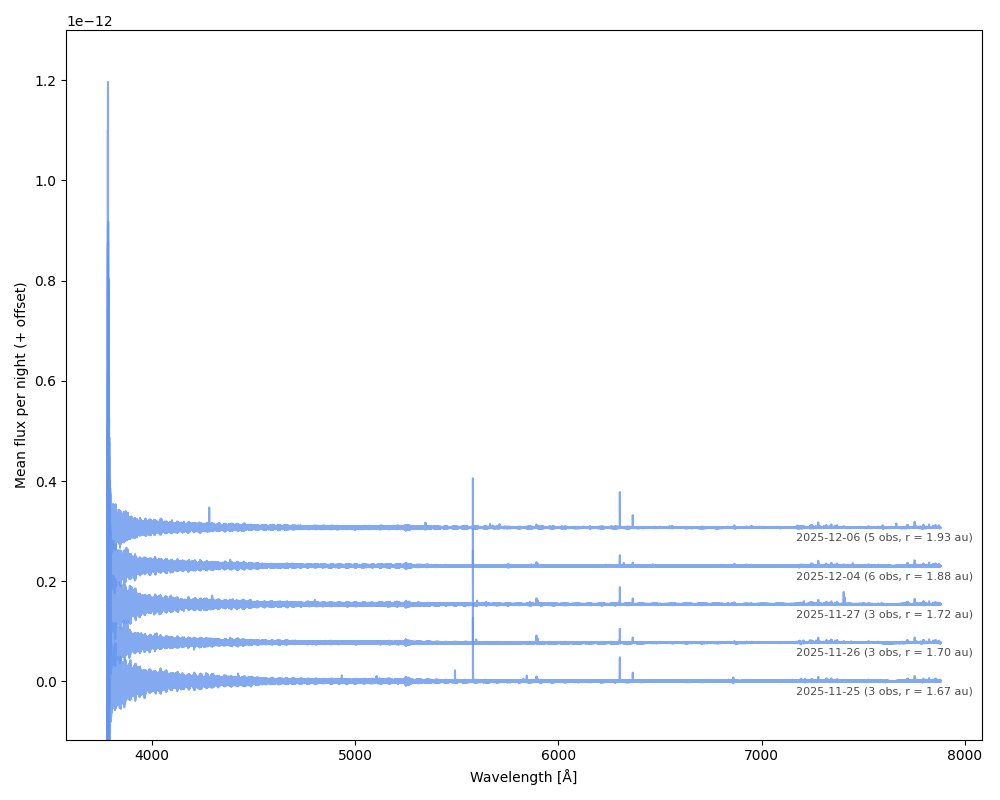

In [96]:
obs = np.concatenate((allobs1, allobs2, allobs3, allobs4, allobs5))
linesA = np.concatenate((lines1A, lines2A, lines3A, lines4A, lines5A))
linesB = np.concatenate((lines1B, lines2B, lines3B, lines4B, lines5B))
per_nigth_length = [len(allobs1), len(allobs2), len(allobs3), len(allobs4), len(allobs5)]

result = stack_fixed(
    obs,
    lines=linesA,
    tol=0.2,
    ref_idx=0,
    clip_sigma=25.0,
    clip_iters=0,
    night_lengths=per_nigth_length,
    visit_directories=visit_directories
)
result_B = stack_fixed(
    obs,
    lines=linesB,
    tol=0.2,
    ref_idx=0,
    clip_sigma=25.0,
    clip_iters=0,
    night_lengths=per_nigth_length,
    visit_directories=visit_directories,
    flux_key='FLUX_FIBER_B',
    err_key='ERR_FIBER_B',
)

In [40]:
print(result.keys())

dict_keys(['Full_Stack', '20251125', '20251126', '20251127', '20251204'])


### Solar Continuum Kurucz model

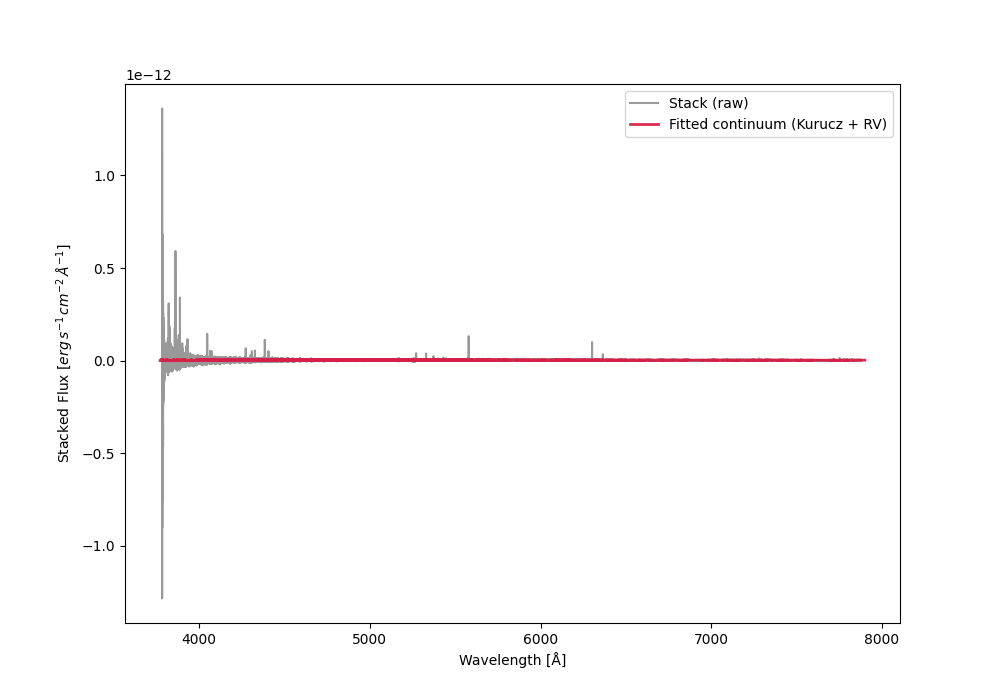

Fitted dlam: -0.1391 Å


Fitted dlam: -0.0877 Å
Fitted dlam: 0.0052 Å
Fitted dlam: 0.0041 Å
Fitted dlam: 0.0060 Å
Fitted dlam: 0.0057 Å
Fitted dlam: 0.0054 Å


In [101]:
# --- Kurucz template (already converted to vacuum in your code) ---
kuruz = pd.read_csv('kurucz_irradiance.txt', delim_whitespace=True, names=['nm', 'flux'])
kuruz['AA'] = kuruz['nm'] * 10.0

wave = np.asarray(kuruz['AA'], dtype=float)
flux = np.asarray(kuruz['flux'], dtype=float)

# pass W/m**2/nm flux to erg / cm^2 /s /AA
flux = flux * u.W / (u.m**2 * u.nm)
flux = flux.to(u.erg / (u.s * u.cm**2 * u.AA))
flux = flux.value

# --- Helper: relativistic Doppler mapping λ_obs -> λ_rest ---
_c_kms = c_light.to_value(u.km / u.s)

def continuum_fitting(stack, stack_B, plot=True, v1=0, v2=0, tell = [], key='', rdot=0):

    global wave, flux

    # clean Kurucz in case there are any NaNs / duplicates
    mask_k = np.isfinite(wave) & np.isfinite(flux)
    wave, flux = wave[mask_k], flux[mask_k]
    ord_k = np.argsort(wave)
    wave, flux = wave[ord_k], flux[ord_k]
    wave, idx_k = np.unique(wave, return_index=True)
    flux = flux[idx_k]

    # Your data
    x_obs = np.asarray(stack['WAVE'], dtype=float)
    y_obs = np.asarray(stack['FLUX_STACK'], dtype=float)
    y_err = np.asarray(stack['ERR_STACK'], dtype=float)

    mdat  = np.isfinite(x_obs) & np.isfinite(y_obs) & np.isfinite(y_err) & (y_err > 0)

    for i in tell:
        telluric_mask = (x_obs > i[0]) & (x_obs < i[1])
        mdat = mdat & (~telluric_mask)
        
        tell_mask = (wave > i[0]) & (wave < i[1])
        wave = wave[~tell_mask]
        flux = flux[~tell_mask]

    x_obs = x_obs[mdat]
    y_obs = y_obs[mdat]
    yerr  = y_err[mdat]

    from astropy.modeling import models

    @models.custom_model
    def KuruczDoppler1D(x, dlam=0.0):
        x = np.asarray(x, dtype=float)
        beta   = rdot / _c_kms
        factor = np.sqrt((1.0 + beta) / (1.0 - beta))
        lam_rest = (x - dlam) / factor
        return np.interp(lam_rest, wave, flux, left=0.0, right=0.0)


    def _scale_model(m0=1.0, name="scale"):
        scale = models.Const1D(amplitude=m0, name=name)
        return scale

    def kurucz_times_poly_with_rv(
        degree=2, dlam0=0.0, dlam_bounds=(-0.2, 0.2),
        m0=1.0, freeze_poly_c0=False
    ):
        scale = _scale_model(m0=m0, name="scale")
        poly  = models.Polynomial1D(degree=degree)
        if freeze_poly_c0:
            # Keep the poly from soaking up overall normalization
            poly.c0.value = 1.0
            poly.c0.fixed = True
        kur   = KuruczDoppler1D(dlam=dlam0, name="kurucz")
        kur.dlam.bounds   = dlam_bounds
        return scale * poly * kur

    # Fit (Kurucz)
    model_k = kurucz_times_poly_with_rv(degree=2, dlam0=0.0, dlam_bounds=(-0.2, 0.2))
    fitter  = fitting.LevMarLSQFitter()
    clipper = SigmaClip(sigma=5.0)
    or_fit  = fitting.FittingWithOutlierRemoval(fitter, clipper, niter=5)
    fitted_kurucz, outmask_k = or_fit(model_k, x_obs, y_obs, weights=1.0 / yerr)

    if plot:
        plt.figure(figsize=(10, 7))
        plt.plot(stack['WAVE'], stack['FLUX_STACK'], alpha=0.8, c='grey', label='Stack (raw)')
        plt.xlabel('Wavelength [Å]')
        plt.ylabel(r'Stacked Flux [$erg\,s^{-1}\,cm^{-2}\,\AA^{-1}$]')
        plt.plot(stack['WAVE'], fitted_kurucz(stack['WAVE']), '-', lw=2, alpha=0.9,
                 label='Fitted continuum (Kurucz + RV)', c='crimson')
        plt.legend()
        plt.show()
    print(f'Fitted dlam: {fitted_kurucz["kurucz"].dlam.value:.4f} Å')
    # evaluate on full grid
    stack['CONTINUUM'] = fitted_kurucz(stack['WAVE'])
    stack['REFLECTANCE'] = fitted_kurucz[1](stack['WAVE'])
    stack['KURUCZ_SHIFTED'] = fitted_kurucz[2](stack['WAVE'])

    kuruz = pd.read_csv('kurucz_irradiance.txt', delim_whitespace=True, names=['nm', 'flux'])
    kuruz['AA'] = kuruz['nm'] * 10.0
    
    # Later we will need the shifted kurucz in the whole range of wavelengths
    wave = np.asarray(kuruz['AA'], dtype=float)
    flux = np.asarray(kuruz['flux'], dtype=float)
    # pass W/m**2/nm flux to erg / cm^2 /s /AA
    flux = flux * u.W / (u.m**2 * u.nm)
    flux = flux.to(u.erg / (u.s * u.cm**2 * u.AA))
    flux = flux.value

    beta   = rdot / _c_kms
    factor = np.sqrt((1.0 + beta) / (1.0 - beta))
    wave_shifted = wave * factor + fitted_kurucz[2].dlam.value
    #save in the folder Pumping_files
    pumping_df = pd.DataFrame({'WAVE': wave_shifted, 'FLUX': flux})
    pumping_df.to_csv(f'Pumping_files/pumping_{key}.txt', sep='\t', index=False)


    # Now that we have fitted_kurucz[2](stack['WAVE']), let do a simpler fit to fiber B, just scale* poly
    x_obs = np.asarray(stack_B['WAVE'], dtype=float)
    y_obs = np.asarray(stack_B['FLUX_STACK'], dtype=float)
    y_err = np.asarray(stack_B['ERR_STACK'], dtype=float)

    mdat  = np.isfinite(x_obs) & np.isfinite(y_obs) & np.isfinite(y_err) & (y_err > 0)

    x_obs = x_obs[mdat]
    y_obs = y_obs[mdat]
    yerr  = y_err[mdat]
    y_obs = y_obs / fitted_kurucz[2](x_obs)
    model = _scale_model(name="scale", m0=fitted_kurucz[0].amplitude.value) * models.Polynomial1D(degree=2, c0 = fitted_kurucz[1].c0.value, c1 = fitted_kurucz[1].c1.value, c2 = fitted_kurucz[1].c2.value)
    fitter  = fitting.LevMarLSQFitter()
    clipper = SigmaClip(sigma=5.0)
    or_fit  = fitting.FittingWithOutlierRemoval(fitter, clipper, niter=5)
    fitted, outmask = or_fit(model, x_obs, y_obs, weights=1.0 / yerr)

    stack_B['CONTINUUM'] = fitted(stack_B['WAVE']) * fitted_kurucz[2](stack_B['WAVE'])
    stack_B['REFLECTANCE'] = fitted[1](stack_B['WAVE'])
    stack_B['KURUCZ_SHIFTED'] = fitted_kurucz[2](stack_B['WAVE'])

    return stack, stack_B

info = [info_obs1, info_obs2, info_obs3, info_obs4, info_obs5]

telluric_ranges = [(6277, 6279), (6867, 6947), (7167, 7202), (7593, 7687)]

rdot = rdot = np.mean([info[-1][key]['rdot_km_s'] for key in info[-1]])
# print(np.mean([info_obs16[key]['deldot_km_s'] for key in info_obs16]))
_, _ = continuum_fitting(result['20251125'], result_B['20251125'], plot=True, v1=-46.8, v2=-4, tell=telluric_ranges, key='20251125', rdot=rdot)


for k, i in enumerate(result.keys()):
    v1 = np.mean([info[k-1][key]['rdot_km_s']+info[k-1][key]['deldot_km_s']for key in info[k-1] if 'sky' not in key and 'solar' not in key])
    rdot = np.mean([info[k-1][key]['rdot_km_s'] for key in info[k-1] if 'sky' not in key and 'solar' not in key])

    v2 = np.mean([info[k-1][key]['deldot_km_s'] for key in info[k-1] if 'sky' not in key and 'solar' not in key])
    result[i], result_B[i] = continuum_fitting(result[i], result_B[i], plot=False, v1=-v1, v2=-v2, key=i, rdot=rdot)

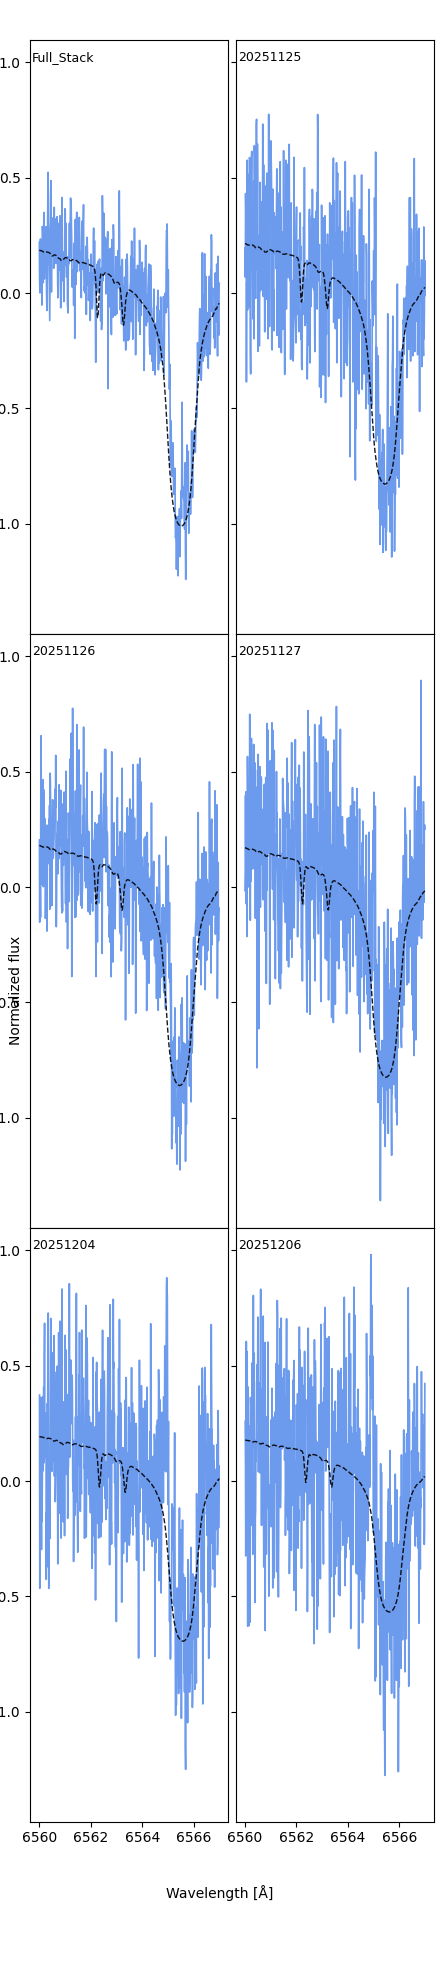

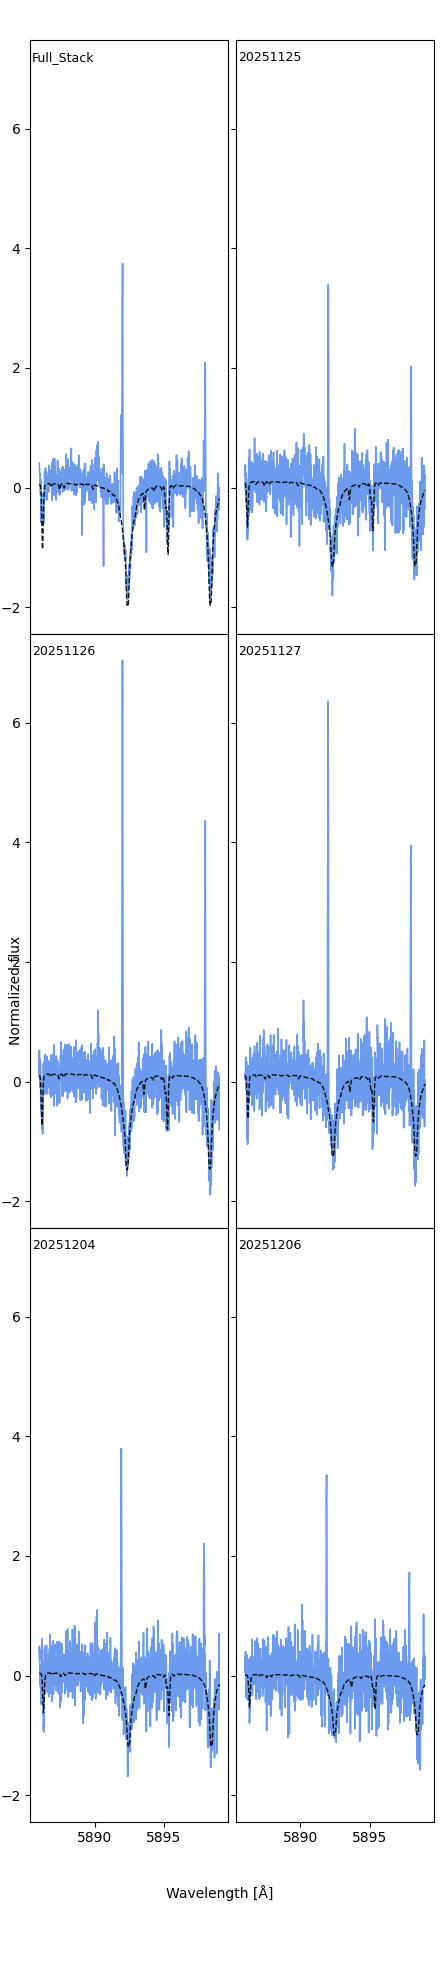

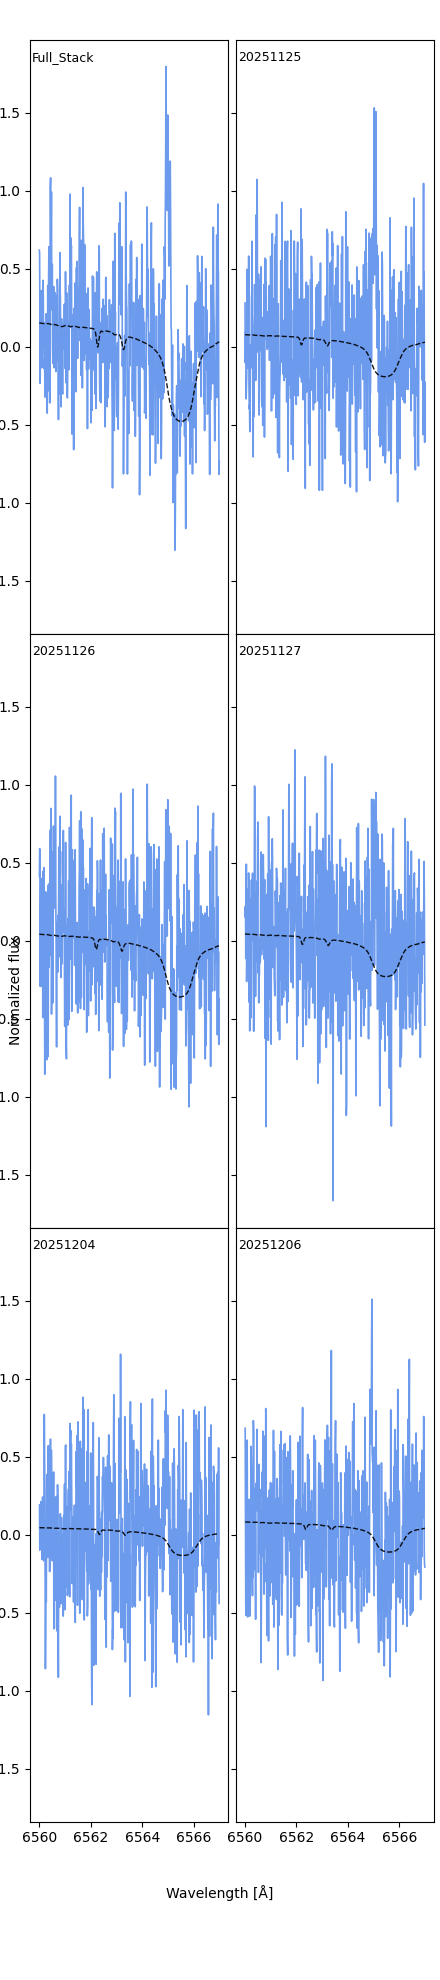

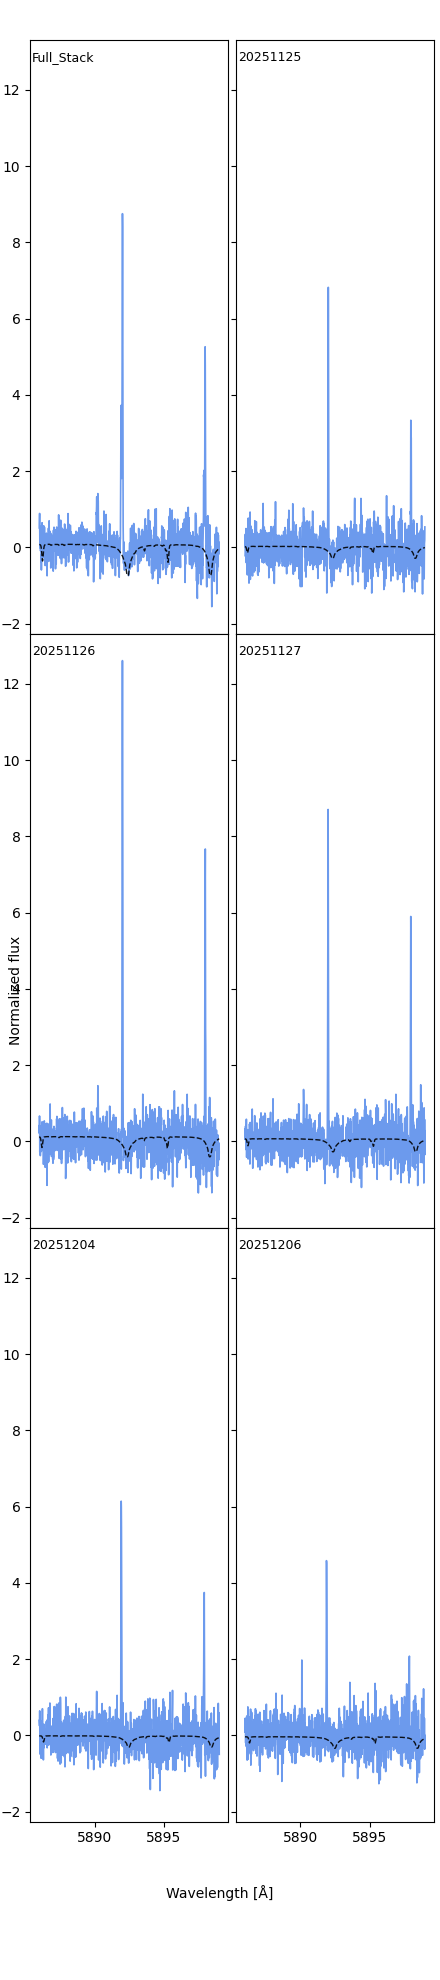

In [102]:
def checking_plot_continuum(window, fiber='A'):
    # --------- params ---------
    wmin, wmax = window[0], window[1]
    nrows = 3
    if fiber == 'A':
        result_to_use = result  # or result_B for fiber B
    if fiber == 'B':
        result_to_use = result_B
    keys = list(result_to_use.keys())
    n = len(keys)
    ncols = int(np.ceil(n / nrows))

    # per-axes width (inches); height auto = 3× this due to box_aspect=3
    per_ax_w = 2.2
    fig_w = per_ax_w * ncols
    fig_h = per_ax_w * (3 * nrows)

    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        sharex=True, sharey=True,
        figsize=(fig_w, fig_h),
        constrained_layout=False,
        gridspec_kw={"wspace": 0.0, "hspace": 0.0}
    )

    # zero gaps between subplots; keep a hair of outer margin for suptitles/labels
    fig.subplots_adjust(left=0.06, right=0.995, bottom=0.08, top=0.98, wspace=0.0, hspace=0.0)

    axes = np.array(axes).reshape(nrows, ncols)

    def norm_by_stack(y, ref):
        med = np.nanmedian(ref)
        p10 = np.nanpercentile(ref, 10)
        p90 = np.nanpercentile(ref, 90)
        scale = p90 - p10
        if not np.isfinite(scale) or scale == 0:
            s = np.nanstd(ref)
            scale = s if (np.isfinite(s) and s > 0) else 1.0
        return (y - med) / scale

    for k, key in enumerate(keys):
        r, c = divmod(k, ncols)
        ax = axes[r, c]

        wave = np.asarray(result_to_use[key]['WAVE'], float)
        mask = (wave >= wmin) & (wave <= wmax) & np.isfinite(wave)

        w = wave[mask]
        f_stack = np.asarray(result_to_use[key]['FLUX_STACK_SKYSUB'], float)[mask]
        f_kur   = np.asarray(result_to_use[key]['CONTINUUM'], float)[mask]

        y_stack = norm_by_stack(f_stack, f_stack)
        y_kur   = norm_by_stack(f_kur,   f_stack)

        ax.plot(w, y_stack, color='cornflowerblue', lw=1.2, alpha=0.95)
        ax.plot(w, y_kur,   color='k', ls='--', lw=1.0, alpha=0.9)

        # title at top-left *inside* each axes
        ax.text(0.01, 0.98, str(key), transform=ax.transAxes,
                ha='left', va='top', fontsize=9)

        # enforce 3:1 height:width
        try:
            ax.set_box_aspect(3.0)
        except Exception:
            pass

    # hide any unused panels cleanly
    for k in range(n, nrows * ncols):
        r = k % nrows
        c = k // nrows
        axes[r, c].set_visible(False)

    # put labels once, centered at the figure level (keeps inter-panel gap at exactly zero)
    fig.supxlabel('Wavelength [Å]', y=0.04, fontsize=10)
    fig.supylabel('Normalized flux', x=0.02, fontsize=10)

    plt.show()

checking_plot_continuum(window=[6560.0, 6567.0], fiber='A')
checking_plot_continuum(window=[5886.0, 5899.0], fiber='A')
checking_plot_continuum(window=[6560.0, 6567.0], fiber='B')
checking_plot_continuum(window=[5886.0, 5899.0], fiber='B')


### Add wave number in cm^-1 (for pgopher)

In [103]:
for j, i in enumerate(result.keys()):
    stack = result[i]
    wave = np.asarray(stack['WAVE'], float)
    wavennumber = 1e8 / wave
    stack['WAVENUMBER'] = wavennumber
    result[i] = stack
    stack_B = result_B[i]
    wave_B = np.asarray(stack_B['WAVE'], float)
    wavennumber_B = 1e8 / wave_B
    stack_B['WAVENUMBER'] = wavennumber_B
    result_B[i] = stack_B

# Save to work in another notebook

In [104]:
#Write as a csv in Output directory every column
# the first row will be the units: AA, erg/s/cm2/AA, erg/s/cm2/AA, -, erg/s/cm2/AA, erg/s/cm2/AA, -, erg/s/cm2/AA, -, erg/s/cm2/AA, cm^-1
import csv
for j, i in enumerate(result.keys()):
    stack = result[i]
    if 'Full' in i:
        i = 'Full_Stack_post'
    output_file = f'Output_spectras/{i}_stack_A.csv'
    with open(output_file, mode='w', newline='') as file:
        writer = csv.writer(file)
        # Write header
        writer.writerow(['AA', 'erg/s/cm2/AA', 'erg/s/cm2/AA', '-', 'erg/s/cm2/AA', 'erg/s/cm2/AA', '-', 'erg/s/cm2/AA', '-', 'erg/s/cm2/AA', 'cm^-1'])
        writer.writerow(stack.keys())
        # Write data rows
        for row in zip(*[stack[key] for key in stack.keys()]):
            writer.writerow(row)

for j, i in enumerate(result_B.keys()):
    stack_B = result_B[i]

    if 'Full' in i:
        i = 'Full_Stack_post'
    output_file_B = f'Output_spectras/{i}_stack_B.csv'
    with open(output_file_B, mode='w', newline='') as file:
        writer = csv.writer(file)
        # Write header
        writer.writerow(['AA', 'erg/s/cm2/AA', 'erg/s/cm2/AA', '-', 'erg/s/cm2/AA', 'erg/s/cm2/AA', '-', 'erg/s/cm2/AA', '-', 'erg/s/cm2/AA', 'cm^-1'])
        writer.writerow(stack_B.keys())
        # Write data rows
        for row in zip(*[stack_B[key] for key in stack_B.keys()]):
            writer.writerow(row)

In [125]:
def load_cn_linelist(path_or_text):
    colspecs = [
        (0,1), (2,3), (4,6), (7,9), (10,15), (16,21), (22,23), (24,25),
        (26,27), (28,29), (30,33), (34,37), (38,49), (50,60), (61,69),
        (70,80), (81,93), (94,106), (107,118)
    ]
    names = ["eS'", "eS''", "v'", "v''", "J'", "J''", "F'", "F''", "p'", "p''",
             "N'", "N''", "Obs", "Cal", "Res", "E''", "A", "f", "Des"]

    if '\n' in path_or_text or path_or_text.strip().startswith("Title:"):
        buf = io.StringIO(path_or_text)
    else:
        buf = open(path_or_text, "r", encoding="utf-8")

    try:
        lines = buf.read().splitlines()
    finally:
        try:
            buf.close()
        except Exception:
            pass

    data_lines = [ln for ln in lines if len(ln) > 2 and ln[0] in "ABX" and ln[1].isspace() and ln[2] in "ABX"]
    df = pd.read_fwf(io.StringIO("\n".join(data_lines)), colspecs=colspecs, names=names)

    num_cols = ["v'", "v''", "J'", "J''", "F'", "F''", "N'", "N''", "Obs", "Cal", "Res", "E''", "A", "f"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    for c in ["eS'", "eS''", "p'", "p''", "Des", "N'"]:
        df[c] = df[c].astype(str).str.strip()

    # ---- Add wavelengths from wavenumber (Cal) ----
    # Units: Cal in cm^-1 → λ_vac(Å) = 1e8 / Cal, λ_vac(nm) = 1e7 / Cal, λ_vac(µm) = 1e4 / Cal
    wn = df["Cal"].to_numpy(dtype=float)
    wn2 = df['Obs'].to_numpy(dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        lam_A  = 1e8 / wn
        lam2_A = 1e8 / wn2

    df["lambda_vac_A_from_Cal"]  = lam_A
    df["lambda_vac_A_from_Obs"]  = lam2_A

    return df

def strongest_per_band(df, by="f", top_k=5, lam_range_A=None):
    """
    Take the top-K strongest lines per band (v', v'') by f or A.
    Optionally restrict to a wavelength window in Å.
    """
    work = df.copy()
    if lam_range_A is not None:
        lam_min, lam_max = lam_range_A
        work = work[(work["lambda_vac_A_from_Cal"] >= lam_min) &
                    (work["lambda_vac_A_from_Cal"] <= lam_max)]

    work[by] = pd.to_numeric(work[by], errors="coerce").abs()
    work = work.dropna(subset=[by])

    def _topk(g):
        return g.sort_values(by=by, ascending=False).head(top_k)

    return (work
            .groupby(["eS'", "eS''", "v'", "v''"], dropna=False, as_index=False)
            .apply(_topk, include_groups=False)
            .reset_index(drop=True))

nickel_lines_A = np.array([3101.55, 3101.88, 3105.47, 3114.12, 3134.11, 3145.72, 3181.74, 3184.37, 3195.57, 3197.11, 3202.14,
                  3214.06, 3217.83, 3221.27, 3221.65, 3225.02, 3232.96, 3234.65, 3243.06, 3248.46, 3250.74, 3271.12,
                  3282.70, 3315.66, 3320.26, 3322.31, 3361.56, 3365.77, 3366.17, 3366.81, 3367.89, 3369.57, 3371.99,
                  3374.22, 3374.64, 3380.57, 3380.85, 3391.05, 3392.99, 3409.58, 3413.48, 3413.94, 3414.76, 3423.71,
                  3433.56, 3437.28, 3446.26, 3452.89, 3458.47, 3461.65, 3467.50, 3469.49, 3472.54, 3483.77, 3485.89,
                  3492.96, 3500.85, 3502.60, 3507.69, 3510.34, 3513.93, 3515.05, 3519.77, 3524.54, 3527.98, 3548.18,
                  3551.53, 3561.75, 3566.37, 3571.87, 3587.93, 3597.70, 3610.46, 3612.74, 3619.39, 3624.73, 3664.10,
                  3669.24, 3670.43, 3674.15, 3688.42, 3693.93, 3722.48, 3736.81, 3739.23, 3775.57, 3783.53, 3807.14,
                  3831.69, 3858.30, 3889.67, 3972.17, 3973.56]) - (3972.4-3859.7)

C_13_N_14_a = load_cn_linelist('CN_lines/13C14N.txt')

C_12_N_15_a = load_cn_linelist('CN_lines/12C15N.txt')

C_12_N_14_a = load_cn_linelist('CN_lines/12C14N.txt')

In [126]:
print(len(C_13_N_14_a), len(C_12_N_15_a), len(C_12_N_14_a))
# filter upper state
C_13_N_14 = C_13_N_14_a[C_13_N_14_a["eS'"]=='B']
C_12_N_14 = C_12_N_14_a[C_12_N_14_a["eS'"]=='B']
C_12_N_15 = C_12_N_15_a[C_12_N_15_a["eS'"]=='B']
# filter lower state = X 
C_13_N_14 = C_13_N_14[C_13_N_14["eS''"]=='X']
C_12_N_14 = C_12_N_14[C_12_N_14["eS''"]=='X']
C_12_N_15 = C_12_N_15[C_12_N_15["eS''"]=='X']

# filter v'=0 and v''=0
C_13_N_14 = C_13_N_14[C_13_N_14["v'"]==0]
C_12_N_14 = C_12_N_14[C_12_N_14["v'"]==0]
C_12_N_15 = C_12_N_15[C_12_N_15["v'"]==0]

C_13_N_14 = C_13_N_14[C_13_N_14["v''"]==0]
C_12_N_14 = C_12_N_14[C_12_N_14["v''"]==0]
C_12_N_15 = C_12_N_15[C_12_N_15["v''"]==0]

# filter N==1
# C_12_N_14 = C_12_N_14[C_12_N_14["N''"]==10]
# C_12_N_15 = C_12_N_15[C_12_N_15["N''"]==10]
# C_13_N_14 = C_13_N_14[C_13_N_14["N''"]==10]

#print(wave)
print(C_13_N_14['lambda_vac_A_from_Cal'])

186383 31348 195120
118324    3876.977728
118325    3877.502514
118326    3878.007908
118327    3878.493862
118328    3878.960347
             ...     
118623    3829.951898
118624    3828.543738
118625    3827.119417
118626    3825.679047
118627    3824.222694
Name: lambda_vac_A_from_Cal, Length: 304, dtype: float64


In [127]:
C_12_N_14['Delta_J'] = C_12_N_14["J''"] - C_12_N_14["J'"]
C_12_N_15['Delta_J'] = C_12_N_15["J''"] - C_12_N_15["J'"]
C_13_N_14['Delta_J'] = C_13_N_14["J''"] - C_13_N_14["J'"]
# Now lets separate in the P and R branches delta J = +1 and -1 i.e J''-J'
C_13_N_14_P = C_13_N_14[C_13_N_14['Delta_J'] == 1]
C_13_N_14_R = C_13_N_14[C_13_N_14['Delta_J'] == -1]
C_12_N_15_P = C_12_N_15[C_12_N_15['Delta_J'] == 1]
C_12_N_15_R = C_12_N_15[C_12_N_15['Delta_J'] == -1]
C_12_N_14_P = C_12_N_14[C_12_N_14['Delta_J'] == 1]
C_12_N_14_R = C_12_N_14[C_12_N_14['Delta_J'] == -1]
# Add a wavelength in AA column so P is greater than 3876 and R less than 3876
C_13_N_14_P = C_13_N_14_P[C_13_N_14_P['lambda_vac_A_from_Cal'] > 3870]
C_13_N_14_R = C_13_N_14_R[C_13_N_14_R['lambda_vac_A_from_Cal'] < 3878]
C_13_N_14_R = C_13_N_14_R[C_13_N_14_R['lambda_vac_A_from_Cal'] > 3867]
C_12_N_15_P = C_12_N_15_P[C_12_N_15_P['lambda_vac_A_from_Cal'] > 3870]
C_12_N_15_R = C_12_N_15_R[C_12_N_15_R['lambda_vac_A_from_Cal'] < 3878]
C_12_N_15_R = C_12_N_15_R[C_12_N_15_R['lambda_vac_A_from_Cal'] > 3867]
C_12_N_14_P = C_12_N_14_P[C_12_N_14_P['lambda_vac_A_from_Cal'] > 3870]
C_12_N_14_R = C_12_N_14_R[C_12_N_14_R['lambda_vac_A_from_Cal'] < 3878]
C_12_N_14_R = C_12_N_14_R[C_12_N_14_R['lambda_vac_A_from_Cal'] > 3867]

# add the sQ
C_13_N_14_sQ = C_13_N_14[C_13_N_14['Delta_J'] == 0]
C_12_N_15_sQ = C_12_N_15[C_12_N_15['Delta_J'] == 0]
C_12_N_14_sQ = C_12_N_14[C_12_N_14['Delta_J'] == 0]

print(len(C_12_N_14_R))


25


In [33]:
# neowise_lines = pd.read_csv('neowise_lines.txt', delim_whitespace=True, names=['Wzve', 'REL_Intensity', 'MOL', 'identifier'])

df = {'Wave': [], 'REL_Intensity': [], 'MOL': [], 'identifier': []
}
with open('Mol_lines/neowise_lines.txt', 'r') as f:
    for line in f.readlines():
        #split by any wthitespace
        line = line.strip().split(' ')
        #take put all the '' elements
        line = [x for x in line if x != '']
        # now lets keep the first three elements as they are and fuse all the rest as the identifier
        line = [float(line[0]), float(line[1]), line[2], ' '.join(line[3:])]
        #append to the table
        df['Wave'].append(line[0])
        df['REL_Intensity'].append(line[1])
        df['MOL'].append(line[2])
        df['identifier'].append(line[3])

neowise_lines = pd.DataFrame(df)

In [128]:
neowise_lines_CN = neowise_lines[neowise_lines['MOL']=='CN']
neowise_lines_CH = neowise_lines[neowise_lines['MOL']=='CH']
neowise_lines_NH2 = neowise_lines[neowise_lines['MOL']=='NH2']
neowise_lines_C_3_ = neowise_lines[neowise_lines['MOL']=='C_3_']
neowise_lines_C_2 = neowise_lines[neowise_lines['MOL']=='C_2_']

#selesct the strongest by ordering by REL_Intensity
neowise_lines_CN = neowise_lines_CN.sort_values(by='REL_Intensity', ascending=False).head(10000)
neowise_lines_CH = neowise_lines_CH.sort_values(by='REL_Intensity', ascending=False).head(10000)
neowise_lines_NH2 = neowise_lines_NH2.sort_values(by='REL_Intensity', ascending=False).head(10000)
neowise_lines_C_3_ = neowise_lines_C_3_.sort_values(by='REL_Intensity', ascending=False).head(10000)
neowise_lines_C_2 = neowise_lines_C_2.sort_values(by='REL_Intensity', ascending=False).head(10000)

#now update the initial neowise_lines
neowise_lines = pd.concat([neowise_lines_CN, neowise_lines_CH, neowise_lines_NH2, neowise_lines_C_3_, neowise_lines_C_2])

In [110]:
CH_PLUS = pd.read_csv('Mol_lines/12C-1H_p__PYT.trans', delim_whitespace=True, names=['u', 'l', 'A_value', 'wavenumber'])
CH_PLUS['WAVE'] = 1e8 / CH_PLUS['wavenumber']
CH_PLUS = CH_PLUS[CH_PLUS['WAVE']>3000]
CH_PLUS = CH_PLUS[CH_PLUS['WAVE']<7000]
#order by A_value
CH_PLUS = CH_PLUS.sort_values(by='A_value', ascending=False).head(100)
CO_PLUS = pd.read_csv('Mol_lines/ECO+_transitions.txt', delim_whitespace=True)
CO_PLUS['WAVE'] = CO_PLUS['ritz']*10
CO_PLUS = CO_PLUS[CO_PLUS['WAVE']>3800]
CO_PLUS = CO_PLUS[CO_PLUS['WAVE']<7000]
CO_PLUS = CO_PLUS.sort_values(by='(vac', ascending=False).head(500)

In [57]:

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

hydrogen = pd.read_csv('Element_lines/hydrogen_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
helium = pd.read_csv('Element_lines/helium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
lythium = pd.read_csv('Element_lines/lythium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
berilium = pd.read_csv('Element_lines/berilium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
boro = pd.read_csv('Element_lines/boro_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
carbon = pd.read_csv('Element_lines/carbon_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
nitrogen = pd.read_csv('Element_lines/nitrogen_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
oxygen = pd.read_csv('Element_lines/oxygen_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
fluor = pd.read_csv('Element_lines/fluor_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
neon = pd.read_csv('Element_lines/neon_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
sodium = pd.read_csv('Element_lines/sodium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
magnesium = pd.read_csv('Element_lines/magnesium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
aluminium = pd.read_csv('Element_lines/aluminium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
silicium = pd.read_csv('Element_lines/silicium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
phos = pd.read_csv('Element_lines/phosphore_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
sulfur = pd.read_csv('Element_lines/sulfur_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
cloro = pd.read_csv('Element_lines/cloro_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
argon = pd.read_csv('Element_lines/argon_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
potasium = pd.read_csv('Element_lines/potasium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
calcium = pd.read_csv('Element_lines/calcium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
scandium = pd.read_csv('Element_lines/scandium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
titanium = pd.read_csv('Element_lines/titanium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
vanadium = pd.read_csv('Element_lines/vanadium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
cromo = pd.read_csv('Element_lines/cromo_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
manganesum = pd.read_csv('Element_lines/manganesum_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
iron = pd.read_csv('Element_lines/iron_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
cobalt = pd.read_csv('Element_lines/cobalt_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
nickel = pd.read_csv('Element_lines/nickel_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
cooper = pd.read_csv('Element_lines/cooper_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
zinc = pd.read_csv('Element_lines/zinc_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
galium = pd.read_csv('Element_lines/galium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
germanium = pd.read_csv('Element_lines/germanium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
arsenic = pd.read_csv('Element_lines/arsenic_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
selenium = pd.read_csv('Element_lines/selenium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
bromine = pd.read_csv('Element_lines/bromine_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
kripton = pd.read_csv('Element_lines/kripton_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
rubidium = pd.read_csv('Element_lines/rubidium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
strontium = pd.read_csv('Element_lines/strontium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])
itrium = pd.read_csv('Element_lines/itrium_lines_air.txt', delim_whitespace=True, names=['WAVE', 'name', 'ion'])

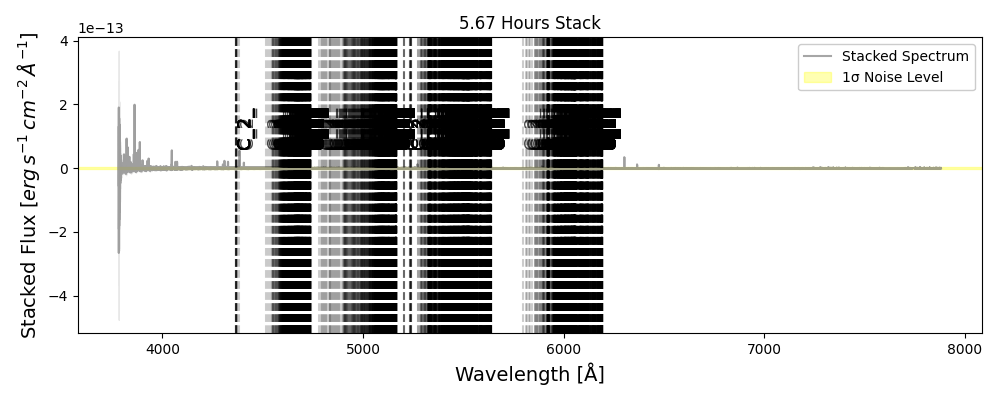

8.85117019069742e-30 2.9750916272776238e-15
63.26689300566388 7.708716230276649e-17
99.8864855724948 1.2017245525575446e-16


OverflowError: Exceeded cell block limit

In [131]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip

result = pd.read_csv('Output_spectras/0920-1206_stack_A.csv', skiprows=1)
window = (result['WAVE'] > 3860) & (result['WAVE'] < 3875)
# Apply sigma clipping to the residuals in the specified window
clipped = sigma_clip(result['FLUX_STACK'][window]-result['CONTINUUM'][window], sigma=3)

# # Compute variance on the clipped data
variance = np.nanvar(clipped.data[~clipped.mask])

plt.figure(figsize=(10, 4))
plt.plot(result['WAVE'], result['FLUX_STACK']-result['CONTINUUM'], color='grey', alpha=0.7, label=f'Stacked Spectrum')
plt.fill_between(result['WAVE'], result['FLUX_STACK'] - result['ERR_STACK'] - result['CONTINUUM'], result['FLUX_STACK'] + result['ERR_STACK'] - result['CONTINUUM'], color='lightgrey', alpha=0.5)


# k=1
# for idx, row in C_12_N_15_R.iterrows():
#     if k == 1:
#         plt.axvline(row['lambda_vac_A_from_Cal'], color='crimson', linestyle='--', alpha=0.5, label='C-12 N-15 Lines')
#         k+=1
#     else:
#         plt.axvline(row['lambda_vac_A_from_Cal'], color='crimson', linestyle='--', alpha=0.2)
# k=1
# for idx, row in C_13_N_14_R.iterrows():
#     if k == 1:
#         plt.axvline(row['lambda_vac_A_from_Cal'], color='steelblue', linestyle='--', alpha=0.5, label='C-13 N-14 Lines')
#         k+=1
#     else:
#         plt.axvline(row['lambda_vac_A_from_Cal'], color='steelblue', linestyle='--', alpha=0.2)
# k=1
# for idx, row in C_12_N_14_R.iterrows():
#     if k == 1:
#         plt.axvline(row['lambda_vac_A_from_Cal'], color='green', linestyle='--', alpha=0.5, label='C-12 N-14 Lines')
#         k+=1
#     else:
#         plt.axvline(row['lambda_vac_A_from_Cal'], color='green', linestyle='--', alpha=0.2)


# k=2
# for idx, row in C_12_N_15_P.iterrows():
#     if k == 1:
#         plt.axvline(row['lambda_vac_A_from_Cal'], color='crimson', linestyle='--', alpha=0.4, label='C-12 N-15 Lines')
#         k+=1
#     else:
#         plt.axvline(row['lambda_vac_A_from_Cal'], color='crimson', linestyle='--', alpha=0.4)
# k=2
# for idx, row in C_13_N_14_P.iterrows():
#     if k == 1:
#         plt.axvline(row['lambda_vac_A_from_Cal'], color='steelblue', linestyle='--', alpha=0.4, label='C-13 N-14 Lines')
#         k+=1
#     else:
#         plt.axvline(row['lambda_vac_A_from_Cal'], color='steelblue', linestyle='--', alpha=0.4)

# k=2
# for idx, row in C_12_N_14_P.iterrows():
#     if k == 1:
#         plt.axvline(row['lambda_vac_A_from_Cal'], color='green', linestyle='--', alpha=0.4, label='C-12 N-14 Lines')
#         k+=1
#     else:
#         plt.axvline(row['lambda_vac_A_from_Cal'], color='green', linestyle='--', alpha=0.4)

# from specutils.utils.wcs_utils import air_to_vac

# for i in iron['WAVE']:
#     if i > 3860 and i < 3885:
#         x = air_to_vac(i*u.AA).to(u.AA).value
#         plt.axvline(x, color='orange', linestyle=':', alpha=0.3)
# print("Variance:", variance)
# plt.axhline(0, color='black', linestyle='-', alpha=0.4)
for idx, row in neowise_lines.iterrows():
    if 'C_2' not in row['MOL']:
        continue

    x = row['Wave']

    x = air_to_vac(row['Wave']* u.AA)
    x = x.to_value(u.AA)
    plt.axvline(x, color='k', linestyle='--', alpha=0.2)

    plt.text(x-1, 7.5e-14, f"{row['MOL']}", rotation=90, fontsize=13, alpha=0.7)
plt.axhspan(-np.sqrt(variance), np.sqrt(variance), color='yellow', alpha=0.3, label='1σ Noise Level')

plt.text(3867.2, 0.5e-13, f'', fontsize=10, color='black')
plt.legend(framealpha=1)
plt.xlabel('Wavelength [Å]', fontsize=14)
plt.ylabel(r'Stacked Flux [$erg\,s^{-1}\,cm^{-2}\,\AA^{-1}$]', fontsize=14)
plt.title(f'{round(340/60, 2)} Hours Stack')
# plt.xlim(3867, 3875)
# plt.ylim(-1e-14, 0.6e-13)
plt.tight_layout()
# plt.savefig('Stacked_spectrum_C12N15_C13N14_R_branch2.png', dpi=300)
plt.show()
print(variance, np.sqrt(variance))
window = (result['WAVE'] > 3872.41) & (result['WAVE'] < 3872.51)
mom0 = np.sum(result['FLUX_STACK'][window]-result['CONTINUUM'][window])
print(mom0/np.sqrt(variance), np.max(result['FLUX_STACK'][window]-result['CONTINUUM'][window])/400)

window = (result['WAVE'] > 3870.22) & (result['WAVE'] < 3870.32)
mom0 = np.sum(result['FLUX_STACK'][window]-result['CONTINUUM'][window])
print(mom0/np.sqrt(variance), np.max(result['FLUX_STACK'][window]-result['CONTINUUM'][window])/400)


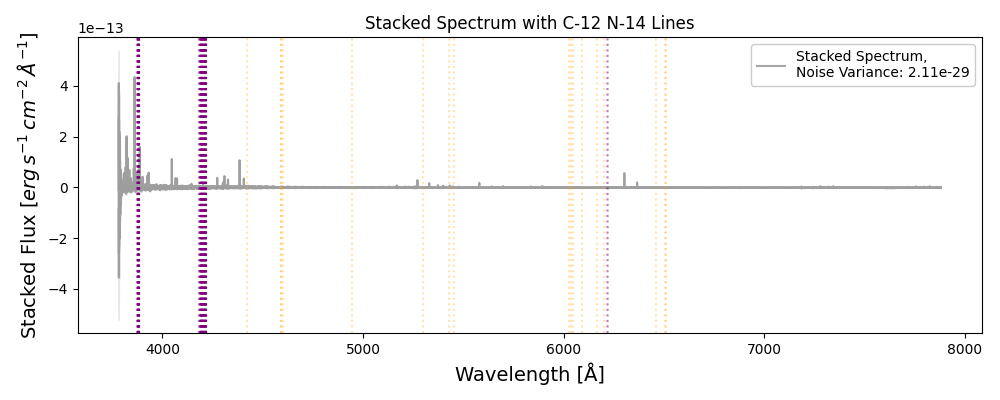

OverflowError: Exceeded cell block limit

In [60]:
%matplotlib widget
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip

result = pd.read_csv('Output_spectras/Full_Stack_post_stack_A.csv', skiprows=1)


plt.figure(figsize=(10, 4))
plt.plot(result['WAVE'], result['FLUX_STACK']-result['CONTINUUM'], color='grey', alpha=0.7, label=f'Stacked Spectrum,\nNoise Variance: {variance:.2e}')
plt.fill_between(result['WAVE'], result['FLUX_STACK'] - result['ERR_STACK']-result['CONTINUUM'], result['FLUX_STACK']+ result['ERR_STACK']-result['CONTINUUM'], color='lightgrey', alpha=0.5)

for i in neowise_lines.iterrows():
    if 'CN' not in i[1]['MOL']:
        continue
    x = i[1]['Wave']
    x = air_to_vac(x*u.AA).to(u.AA).value
    plt.axvline(x, color='purple', linestyle=':', alpha=0.3)

# print("Variance:", variance)

plt.legend(framealpha=1)
plt.xlabel('Wavelength [Å]', fontsize=14)
plt.ylabel(r'Stacked Flux [$erg\,s^{-1}\,cm^{-2}\,\AA^{-1}$]', fontsize=14)
plt.title('Stacked Spectrum with C-12 N-14 Lines')
# plt.xlim(5156, 5169)
# plt.ylim(-1e-15, 5e-15)
# plt.xlim(4295, 4320)
# plt.ylim(-5e-15, 5e-14)
# plt.xlim(6180, 6194)
for i in phos['WAVE']:
        x = air_to_vac(i*u.AA).to(u.AA).value
        plt.axvline(x, color='orange', linestyle=':', alpha=0.3)
plt.tight_layout()
# plt.savefig('Stacked_spectrum_C12N15_C13N14_R_branch2.png', dpi=300)
plt.show()
# c3 4052-4058

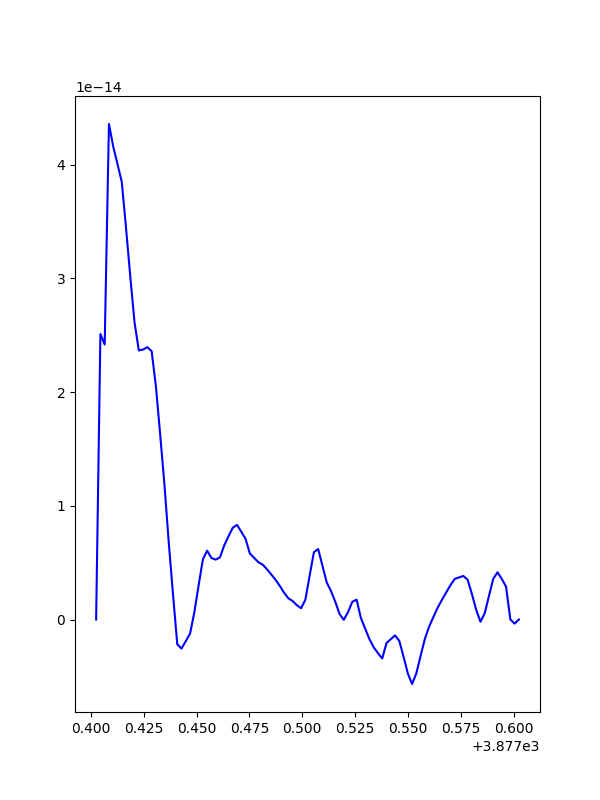

In [106]:
def stack_lines(wave, spec, line, window=5.0, n_points=200):
    # Define a common wavelength grid *relative to the line center*
    rel_grid = np.linspace(-window/2, window/2, n_points)

    lines = []
    line = line.sort_values(by='A', ascending=False).head(3)
    for _, i in line.iterrows():
        center = i['lambda_vac_A_from_Cal']
        wmin = center - window/2
        wmax = center + window/2

        mask = (wave >= wmin) & (wave <= wmax)
        if not np.any(mask):
            continue

        w = wave[mask]
        f = spec[mask]

        # Construct absolute grid for this line
        target_w = center + rel_grid

        # Interpolate spectrum onto the common grid
        f_interp = np.interp(target_w, w, f, left=np.nan, right=np.nan)

        lines.append(f_interp)

    # Convert to array and take median while ignoring NaNs
    stack = np.nansum(np.array(lines), axis=0)

    # Return the final wavelength grid (one size fits all)
    final_w = rel_grid + np.nanmedian(line['lambda_vac_A_from_Cal'])

    return stack, final_w


stacked, w = stack_lines(
    np.asarray(result['WAVE'], float),
    np.asarray(result['FLUX_STACK'] - result['CONTINUUM'], float),
    C_13_N_14_P,
    window=0.2,
    n_points=100
)

plt.figure(figsize=(6, 8))
plt.plot(w, stacked, color='blue', label='C-13 N-15 R-branch')
plt.show()


In [80]:
C_12_N_14_R

,eS',eS'',v',v'',J',J'',F',F'',p',p'',...,Obs,Cal,Res,E'',A,f,Des,lambda_vac_A_from_Cal,lambda_vac_A_from_Obs,Delta_J
120411,B,X,0,0,1.5,0.5,1,1,e,e,...,25801.787,25801.7964,-0.00940,0.0000,4989778.0,0.022473,rR1(0.5),3875.699135,3875.700547,-1.0
120412,B,X,0,0,2.5,1.5,1,1,e,e,...,25805.840,25805.8539,-0.01386,3.7858,5990942.0,0.020231,rR1(1.5),3875.089752,3875.091840,-1.0
120413,B,X,0,0,3.5,2.5,1,1,e,e,...,25810.025,25810.0463,-0.02126,11.3536,6422404.0,0.019272,rR1(2.5),3874.460310,3874.463508,-1.0
120414,B,X,0,0,4.5,3.5,1,1,e,e,...,25814.373,25814.3734,-0.00042,22.7030,6664045.0,0.018741,rR1(3.5),3873.810859,3873.810919,-1.0
120415,B,X,0,0,5.5,4.5,1,1,e,e,...,25818.831,25818.8352,-0.00417,37.8337,6819468.0,0.018404,rR1(4.5),3873.141419,3873.142049,-1.0
120416,B,X,0,0,6.5,5.5,1,1,e,e,...,25823.391,25823.4313,-0.04033,56.7451,6928520.0,0.018173,rR1(5.5),3872.452070,3872.458114,-1.0
120417,B,X,0,0,7.5,6.5,1,1,e,e,...,25828.053,25828.1617,-0.10873,79.4362,7009796.0,0.018004,rR1(6.5),3871.742835,3871.759130,-1.0
120418,B,X,0,0,8.5,7.5,1,1,e,e,...,25833.049,25833.0262,0.02283,105.9063,7073142.0,0.017876,rR1(7.5),3871.013765,3871.010348,-1.0
120419,B,X,0,0,9.5,8.5,1,1,e,e,...,25838.035,25838.0245,0.01055,136.1543,7124256.0,0.017776,rR1(8.5),3870.264927,3870.263354,-1.0
120420,B,X,0,0,10.5,9.5,1,1,e,e,...,25843.162,25843.1564,0.00561,170.1789,7166667.0,0.017696,rR1(9.5),3869.496375,3869.495536,-1.0


In [117]:
def find_ephemeris_path(
    date_obs,
    base_dir = "Ephemeris",
    filename_pattern = "horizons_results_{date}.txt",
    try_prev_day= True,):
    ymd = _normalize_yyyymmdd(date_obs)
    d0 = datetime.strptime(ymd, "%Y%m%d").date()

    candidates = [d0]
    if try_prev_day:
        candidates.append(d0 - timedelta(days=1))

    tried = []
    for d in candidates:
        p = Path(base_dir) / filename_pattern.format(date=d.strftime("%Y%m%d"))
        tried.append(str(p))
        if p.exists():
            return p

    raise FileNotFoundError(
        "Ephemeris file not found. Tried:\n  " + "\n  ".join(tried)
    )

# read the epehemeris file into a dataframe
def horizons_to_dataframe(path):
    with open(path, "r", encoding="utf-8", errors="replace") as f:
        txt = f.read()
    # isolate the data block
    try:
        block = txt.split("$$SOE", 1)[1].split("$$EOE", 1)[0]
    except IndexError:
        raise ValueError("Could not find $$SOE/$$EOE block.")
    # keep only real CSV lines (skip the “>..... Cut-off .....<” messages)
    lines = [
        ln for ln in block.splitlines()
        if ln.strip() and not ln.lstrip().startswith(">")
    ]
    block = "\n".join(lines)
    # read CSV; there are lots of spaces after commas
    df = pd.read_csv(
        io.StringIO(block),
        header=None,
        engine="python",
        skipinitialspace=True,  # trims spaces AFTER commas
        dtype=str               # read as strings first so we can strip cleanly
    )
    # drop trailing all-empty column caused by the final comma
    if df.shape[1] >= 15:
        last = df.columns[-1]
        if df[last].isna().all() or df[last].astype(str).str.strip().eq("").all():
            df = df.iloc[:, :-1]
    df.columns = [
        "datetime_utc","jd_ut","sun_presence","moon_presence","ra_hms","dec_dms","delta_au","deldot_km_s",
        "dra_cosdec_arcsec_per_hr","ddec_arcsec_per_hr","n_mag",
        "r_au","rdot_km_s",
    ]

    # strip whitespace on all string cols (crucial for the first field!)
    for c in ["datetime_utc","sun_presence","moon_presence","ra_hms","dec_dms"]:
        df[c] = df[c].astype(str).str.strip()
    # parse datetime now that the leading space is gone
    df["datetime_utc"] = pd.to_datetime(df["datetime_utc"], format="%Y-%b-%d %H:%M:%S")
    # convert numerics
    for col in ["jd_ut","dra_cosdec_arcsec_per_hr","ddec_arcsec_per_hr","n_mag",
                "r_au","rdot_km_s","delta_au","deldot_km_s"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    # normalize presence flags: empty/whitespace -> NA
    df.replace({"sun_presence": pd.NA}, inplace=True)
    df.replace({"moon_presence": pd.NA}, inplace=True)
    # RA/Dec to degrees
    def ra_to_deg(s):
        h, m, sec = s.split()
        return (float(h) + float(m)/60 + float(sec)/3600) * 15.0
    def dec_to_deg(s):
        d, m, sec = s.split()
        sign = -1 if d.startswith("-") else 1
        d = abs(float(d))
        return sign * (d + float(m)/60 + float(sec)/3600)
    df["ra_deg"]  = df["ra_hms"].map(ra_to_deg)
    df["dec_deg"] = df["dec_dms"].map(dec_to_deg)
    df['MJD'] = utc_to_mjd(df['datetime_utc'])
    return df

jup = horizons_to_dataframe('Jupyter.txt')
three_i = horizons_to_dataframe('3I.txt')
print(jup.head())

def hms_to_deg(hms_str):
    h, m, s = map(float, hms_str.split())
    return 15.0 * (h + m/60.0 + s/3600.0)  # 1h = 15°

def dms_to_deg(dms_str):
    parts = dms_str.split()
    d = float(parts[0])
    m = float(parts[1])
    s = float(parts[2])
    sign = -1.0 if d < 0 else 1.0
    d = abs(d)
    return sign * (d + m/60.0 + s/3600.0)

three_i["RA_deg"]  = three_i["ra_hms"].apply(hms_to_deg)
three_i["DEC_deg"] = three_i["dec_dms"].apply(dms_to_deg)
jup["RA_deg"]  = jup["ra_hms"].apply(hms_to_deg)
jup["DEC_deg"] = jup["dec_dms"].apply(dms_to_deg)


         datetime_utc         jd_ut sun_presence moon_presence  \
0 2026-03-15 00:00:00  2.461114e+06            A           nan   
1 2026-03-15 00:01:00  2.461115e+06            A           nan   
2 2026-03-15 00:02:00  2.461115e+06            A           nan   
3 2026-03-15 00:03:00  2.461115e+06            A           nan   
4 2026-03-15 00:04:00  2.461115e+06            A           nan   

            ra_hms          dec_dms  delta_au  deldot_km_s  \
0  07 04 10.634076  +22 58 37.82183  4.803576    26.135660   
1  07 04 10.635829  +22 58 37.82071  4.803587    26.137479   
2  07 04 10.637583  +22 58 37.81958  4.803597    26.139299   
3  07 04 10.639337  +22 58 37.81844  4.803608    26.141119   
4  07 04 10.641091  +22 58 37.81728  4.803618    26.142940   

   dra_cosdec_arcsec_per_hr  ddec_arcsec_per_hr  n_mag  r_au  rdot_km_s  \
0                       NaN                 NaN    NaN   NaN        NaN   
1                       NaN                 NaN    NaN   NaN        NaN   
2    

In [121]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. Load the ephemerides
# -----------------------------
atlas = three_i
jupiter = jup

# Convert time to datetime (optional but handy)
atlas["datetime"] = pd.to_datetime(atlas["datetime_utc"])
jupiter["datetime"] = pd.to_datetime(jupiter["datetime_utc"])

# -----------------------------
# 2. Align the two tables in time
# -----------------------------
# If JPL uses exactly the same step times for both, this simple merge works:
merged = pd.merge(
    atlas,
    jupiter,
    on="datetime",
    suffixes=("_3I", "_JUP")
)

# If times are slightly different, you could use merge_asof instead:
# merged = pd.merge_asof(
#     atlas.sort_values("datetime"),
#     jupiter.sort_values("datetime"),
#     on="datetime",
#     direction="nearest",
#     suffixes=("_3I", "_JUP")
# )

# -----------------------------
# 3. Compute angular separation γ
# -----------------------------
# RA/DEC must be in radians for trig functions
ra1  = np.deg2rad(merged["ra_deg_3I"])
dec1 = np.deg2rad(merged["dec_deg_3I"])
ra2  = np.deg2rad(merged["ra_deg_JUP"])
dec2 = np.deg2rad(merged["dec_deg_JUP"])

# Cosine of angle γ between the two directions (standard spherical formula)
cos_gamma = (
    np.sin(dec1) * np.sin(dec2) +
    np.cos(dec1) * np.cos(dec2) * np.cos(ra1 - ra2)
)

# Numerical issues: clamp into [-1, 1]
cos_gamma = np.clip(cos_gamma, -1.0, 1.0)

gamma = np.arccos(cos_gamma)  # in radians (optional to keep)

# -----------------------------
# 4. Compute distance between 3I and Jupiter
# -----------------------------
# R_au_3I and R_au_JUP are observer ranges in AU (from JPL quantity 20)
R1 = merged["delta_au_3I"]
R2 = merged["delta_au_JUP"]

# Law of cosines: d^2 = R1^2 + R2^2 - 2*R1*R2*cos(gamma)
merged["dist_au"] = np.sqrt(R1**2 + R2**2 - 2.0 * R1 * R2 * cos_gamma)

# Convert to km if you like
AU_IN_KM = 149_597_870.7
merged["dist_km"] = merged["dist_au"] * AU_IN_KM

# -----------------------------
# 5. Closest approach
# -----------------------------
closest = merged.loc[merged["dist_km"].idxmin()]

print("Closest approach between 3I/ATLAS and Jupiter:")
print("Time         :", closest["datetime"])
print("Distance (AU):", closest["dist_au"])
print("Distance (km):", closest["dist_km"])

# Save full distance time series if you want
merged.to_csv("3I_Jupiter_distance_timeseries.csv", index=False)


Closest approach between 3I/ATLAS and Jupiter:
Time         : 2026-03-16 18:52:00
Distance (AU): 0.3584464250790571
Distance (km): 53622821.95185402


In [122]:
from astropy import units as u
fwefd = 0.35821	*u.AU
print(fwefd.to(u.km))

53587453.263446994 km
